MedConvMixer-LT

In [ ]:
!pip install -q medmnist albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 12.8 MB/s eta 0:00:00


In [ ]:
import os
import gc
import cv2
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from tqdm import tqdm

from torch.cuda.amp import (
    autocast,
    GradScaler
)

from torch.optim.lr_scheduler import (
    CosineAnnealingWarmRestarts
)

from torch.utils.data import (
    Dataset,
    DataLoader
)

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.preprocessing import label_binarize

import albumentations as A

from albumentations.pytorch import ToTensorV2

import medmnist

from medmnist import OCTMNIST


warnings.filterwarnings("ignore")


def seed_everything(seed=42):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    torch.cuda.manual_seed(seed)

    torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False


seed_everything(42)


device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"

)


print(device)

if torch.cuda.is_available():

    print(torch.cuda.get_device_name(0))

cuda
NVIDIA L4


In [ ]:
train_transform = A.Compose([

    A.HorizontalFlip(p=0.5),

    A.VerticalFlip(p=0.5),

    A.RandomBrightnessContrast(p=0.2),

    A.ShiftScaleRotate(

        shift_limit=0.05,

        scale_limit=0.05,

        rotate_limit=10,

        p=0.1

    ),

    A.Normalize(

        mean=(0.5,),

        std=(0.5,)

    ),

    ToTensorV2()

])


val_transform = A.Compose([

    A.Normalize(

        mean=(0.5,),

        std=(0.5,)

    ),

    ToTensorV2()

])

In [ ]:
class OCTDataset(Dataset):

    def __init__(

        self,

        split='train',

        transform=None

    ):

        self.dataset = OCTMNIST(

            split=split,

            download=True

        )

        self.transform = transform

    def __len__(self):

        return len(self.dataset)

    def __getitem__(self, idx):

        image, label = self.dataset[idx]

        image = np.array(image)

        if self.transform:

            augmented = self.transform(

                image=image

            )

            image = augmented["image"]

        label = torch.tensor(

            label,

            dtype=torch.long

        ).squeeze()

        return image, label

In [ ]:
train_dataset = OCTDataset(

    split='train',

    transform=train_transform

)


val_dataset = OCTDataset(

    split='val',

    transform=val_transform

)


test_dataset = OCTDataset(

    split='test',

    transform=val_transform

)

100%|██████████| 54.9M/54.9M [01:23<00:00, 660kB/s]


In [ ]:
BATCH_SIZE = 32


train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=2,

    pin_memory=True,

    persistent_workers=False

)


val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2,

    pin_memory=True,

    persistent_workers=False

)


test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2,

    pin_memory=True,

    persistent_workers=False

)

In [ ]:
class FocalLoss(nn.Module):

    def __init__(

        self,

        alpha=1,

        gamma=2

    ):

        super().__init__()

        self.alpha = alpha

        self.gamma = gamma

    def forward(

        self,

        inputs,

        targets

    ):

        ce_loss = nn.functional.cross_entropy(

            inputs,

            targets,

            reduction='none'

        )

        pt = torch.exp(-ce_loss)

        focal_loss = (

            self.alpha

            *

            (1 - pt) ** self.gamma

            *

            ce_loss

        )

        return focal_loss.mean()

In [ ]:
criterion = FocalLoss(
    alpha=1,
    gamma=2
)

In [ ]:
def compute_macro_auc(

    y_true,

    y_probs,

    num_classes=4

):

    y_true_bin = label_binarize(

        y_true,

        classes=list(range(num_classes))

    )

    auc = roc_auc_score(

        y_true_bin,

        y_probs,

        average='macro',

        multi_class='ovr'

    )

    return auc

In [ ]:
class PatchEmbedding(nn.Module):

    def __init__(
        self,
        in_channels=1,
        dim=128,
        patch_size=2
    ):

        super().__init__()

        self.proj = nn.Sequential(

            nn.Conv2d(

                in_channels,

                dim,

                kernel_size=patch_size,

                stride=patch_size

            ),

            nn.GELU(),

            nn.BatchNorm2d(dim)

        )

    def forward(self, x):

        return self.proj(x)

In [ ]:
class ConvMixerBlock(nn.Module):

    def __init__(
        self,
        dim,
        kernel_size=5
    ):

        super().__init__()

        self.depthwise = nn.Sequential(

            nn.Conv2d(

                dim,

                dim,

                kernel_size,

                groups=dim,

                padding="same"

            ),

            nn.GELU(),

            nn.BatchNorm2d(dim)

        )

        self.pointwise = nn.Sequential(

            nn.Conv2d(

                dim,

                dim,

                kernel_size=1

            ),

            nn.GELU(),

            nn.BatchNorm2d(dim)

        )

    def forward(self, x):

        residual = x

        x = self.depthwise(x)

        x = x + residual

        x = self.pointwise(x)

        return x

In [ ]:
class MedConvMixerLT(nn.Module):

    def __init__(

        self,

        dim=128,

        depth=8,

        num_classes=4

    ):

        super().__init__()

        self.patch_embed = PatchEmbedding(

            in_channels=1,

            dim=dim,

            patch_size=2

        )

        self.blocks = nn.Sequential(

            *[

                ConvMixerBlock(

                    dim=dim,

                    kernel_size=5

                )

                for _ in range(depth)

            ]

        )

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(

            dim,

            num_classes

        )

    def forward(self, x):

        x = self.patch_embed(x)

        x = self.blocks(x)

        x = self.pool(x)

        x = torch.flatten(x,1)

        x = self.dropout(x)

        x = self.fc(x)

        return x

In [ ]:
model_convmixer = MedConvMixerLT().to(device)

dummy = torch.randn(

    2,

    1,

    28,

    28

).to(device)

output = model_convmixer(dummy)

print(output.shape)

torch.Size([2, 4])


In [ ]:
model_convmixer = MedConvMixerLT(

    dim=64,

    depth=4

).to(device)


optimizer_convmixer = optim.AdamW(

    model_convmixer.parameters(),

    lr=1e-3,

    weight_decay=1e-4

)


scheduler_convmixer = CosineAnnealingWarmRestarts(

    optimizer_convmixer,

    T_0=5

)


scaler_convmixer = GradScaler()

In [ ]:
best_val_loss_convmixer = np.inf

patience_convmixer = 6

counter_convmixer = 0

In [ ]:
history_convmixer = {

    "train_loss": [],

    "val_loss": [],

    "val_auc": [],

    "val_acc": []

}

In [ ]:
import os
import gc
import time
import numpy as np

EPOCHS = 50

CHECKPOINT_PATH = "convmixer_checkpoint.pth"

BEST_MODEL_PATH = "best_convmixer_model.pth"

start_epoch = 0


if os.path.exists(CHECKPOINT_PATH):

    print("\nCheckpoint found. Loading...")

    checkpoint = torch.load(

        CHECKPOINT_PATH,

        map_location=device,

        weights_only=False

    )

    model_convmixer.load_state_dict(

        checkpoint["model_state_dict"]

    )

    optimizer_convmixer.load_state_dict(

        checkpoint["optimizer_state_dict"]

    )

    scheduler_convmixer.load_state_dict(

        checkpoint["scheduler_state_dict"]

    )

    scaler_convmixer.load_state_dict(

        checkpoint["scaler_state_dict"]

    )

    history_convmixer = checkpoint["history"]

    best_val_loss_convmixer = checkpoint["best_val_loss"]

    counter_convmixer = checkpoint["counter"]

    start_epoch = checkpoint["epoch"] + 1

    print(

        f"Training resumed from epoch {start_epoch}"

    )

else:

    print("\nNo checkpoint found.")

    print("Starting training from scratch.")

    history_convmixer = {

        "train_loss": [],

        "val_loss": [],

        "val_auc": [],

        "val_acc": []

    }

    best_val_loss_convmixer = np.inf

    counter_convmixer = 0


for epoch in range(start_epoch, EPOCHS):

    epoch_start = time.time()

    torch.cuda.empty_cache()

    gc.collect()

    model_convmixer.train()

    train_loss = 0.0


    loop = tqdm(

        train_loader,

        total=len(train_loader),

        leave=True

    )


    for batch_idx, (images, labels) in enumerate(loop):

        images = images.to(device)

        labels = labels.to(device)

        optimizer_convmixer.zero_grad(set_to_none=True)


        with autocast():

            outputs = model_convmixer(images)

            loss = criterion(

                outputs,

                labels

            )


        scaler_convmixer.scale(loss).backward()

        scaler_convmixer.step(

            optimizer_convmixer

        )

        scaler_convmixer.update()

        train_loss += loss.item()


        current_lr = optimizer_convmixer.param_groups[0]["lr"]


        loop.set_description(

            f"Epoch [{epoch+1}/{EPOCHS}]"

        )

        loop.set_postfix({

            "Loss": f"{loss.item():.4f}",

            "LR": f"{current_lr:.6f}"

        })


    train_loss /= len(train_loader)

    scheduler_convmixer.step()


    model_convmixer.eval()

    val_loss = 0.0

    y_true = []

    y_probs = []

    y_preds = []


    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.to(device)


            with autocast():

                outputs = model_convmixer(images)

                loss = criterion(

                    outputs,

                    labels

                )

                probs = torch.softmax(

                    outputs,

                    dim=1

                )


            preds = torch.argmax(

                probs,

                dim=1

            )


            val_loss += loss.item()


            y_true.extend(

                labels.cpu().numpy()

            )


            y_probs.extend(

                probs.cpu().numpy()

            )


            y_preds.extend(

                preds.cpu().numpy()

            )


    val_loss /= len(val_loader)


    val_auc = compute_macro_auc(

        np.array(y_true),

        np.array(y_probs)

    )


    val_acc = accuracy_score(

        y_true,

        y_preds

    )


    history_convmixer["train_loss"].append(

        train_loss

    )

    history_convmixer["val_loss"].append(

        val_loss

    )

    history_convmixer["val_auc"].append(

        val_auc

    )

    history_convmixer["val_acc"].append(

        val_acc

    )


    epoch_time = time.time() - epoch_start


    print("\n" + "="*60)

    print(f"Epoch {epoch+1}/{EPOCHS}")

    print("="*60)

    print(f"Train Loss      : {train_loss:.4f}")

    print(f"Validation Loss : {val_loss:.4f}")

    print(f"Validation Acc  : {val_acc:.4f}")

    print(f"Validation AUC  : {val_auc:.4f}")

    print(f"Learning Rate   : {current_lr:.6f}")

    print(f"Epoch Time      : {epoch_time:.2f} sec")

    print("="*60)


    checkpoint = {

        "epoch": epoch,

        "model_state_dict": model_convmixer.state_dict(),

        "optimizer_state_dict": optimizer_convmixer.state_dict(),

        "scheduler_state_dict": scheduler_convmixer.state_dict(),

        "scaler_state_dict": scaler_convmixer.state_dict(),

        "history": history_convmixer,

        "best_val_loss": best_val_loss_convmixer,

        "counter": counter_convmixer

    }


    torch.save(

        checkpoint,

        CHECKPOINT_PATH

    )


    print("Checkpoint saved successfully.")


    if val_loss < best_val_loss_convmixer:

        best_val_loss_convmixer = val_loss

        counter_convmixer = 0


        torch.save(

            model_convmixer.state_dict(),

            BEST_MODEL_PATH

        )


        print("Best model updated and saved.")

    else:

        counter_convmixer += 1

        print(

            f"EarlyStopping Counter: {counter_convmixer}"

        )


    if counter_convmixer >= patience_convmixer:

        print("\nEarly stopping triggered.")

        break


    torch.cuda.empty_cache()

    gc.collect()


No checkpoint found.
Starting training from scratch.


Epoch [1/50]: 100%|██████████| 3047/3047 [00:35<00:00, 85.41it/s, Loss=0.0314, LR=0.001000] 



Epoch 1/50
Train Loss      : 0.2487
Validation Loss : 0.1627
Validation Acc  : 0.8648
Validation AUC  : 0.9423
Learning Rate   : 0.001000
Epoch Time      : 37.70 sec
Checkpoint saved successfully.
Best model updated and saved.


Epoch [2/50]: 100%|██████████| 3047/3047 [00:31<00:00, 97.92it/s, Loss=1.1352, LR=0.000905] 



Epoch 2/50
Train Loss      : 0.1819
Validation Loss : 0.1531
Validation Acc  : 0.8695
Validation AUC  : 0.9494
Learning Rate   : 0.000905
Epoch Time      : 32.44 sec
Checkpoint saved successfully.
Best model updated and saved.


...


Epoch 48/50
Train Loss      : 0.1063
Validation Loss : 0.0995
Validation Acc  : 0.9115
Validation AUC  : 0.9698
Learning Rate   : 0.000655
Epoch Time      : 33.04 sec
Checkpoint saved successfully.
EarlyStopping Counter: 3


Epoch [49/50]: 100%|██████████| 3047/3047 [00:31<00:00, 97.09it/s, Loss=0.0969, LR=0.000345]



Epoch 49/50
Train Loss      : 0.1007
Validation Loss : 0.0957
Validation Acc  : 0.9129
Validation AUC  : 0.9709
Learning Rate   : 0.000345
Epoch Time      : 32.75 sec
Checkpoint saved successfully.
Best model updated and saved.


Epoch [50/50]: 100%|██████████| 3047/3047 [00:31<00:00, 95.77it/s, Loss=0.0160, LR=0.000095]



Epoch 50/50
Train Loss      : 0.0955
Validation Loss : 0.0991
Validation Acc  : 0.9131
Validation AUC  : 0.9722
Learning Rate   : 0.000095
Epoch Time      : 33.23 sec
Checkpoint saved successfully.
EarlyStopping Counter: 1


In [ ]:
model_convmixer.load_state_dict(

    torch.load(

        "best_convmixer_model.pth",

        map_location=device,

        weights_only=False

    )

)

model_convmixer.eval()

print("Best ConvMixer model loaded.")

Best ConvMixer model loaded.


In [ ]:
y_true_convmixer = []

y_probs_convmixer = []

y_preds_convmixer = []


with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)


        with autocast():

            outputs = model_convmixer(images)

            probs = torch.softmax(

                outputs,

                dim=1

            )


        preds = torch.argmax(

            probs,

            dim=1

        )


        y_true_convmixer.extend(

            labels.numpy()

        )


        y_probs_convmixer.extend(

            probs.cpu().numpy()

        )


        y_preds_convmixer.extend(

            preds.cpu().numpy()

        )

In [ ]:
from sklearn.metrics import (

    classification_report,

    precision_score,

    recall_score,

    f1_score

)


test_acc_convmixer = accuracy_score(

    y_true_convmixer,

    y_preds_convmixer

)


test_auc_convmixer = compute_macro_auc(

    np.array(y_true_convmixer),

    np.array(y_probs_convmixer)

)


macro_precision_convmixer = precision_score(

    y_true_convmixer,

    y_preds_convmixer,

    average='macro'

)


macro_recall_convmixer = recall_score(

    y_true_convmixer,

    y_preds_convmixer,

    average='macro'

)


macro_f1_convmixer = f1_score(

    y_true_convmixer,

    y_preds_convmixer,

    average='macro'

)


print("\n========== CONVMIXER FINAL RESULTS ==========\n")

print(f"Accuracy        : {test_acc_convmixer:.4f}")

print(f"Macro-AUC       : {test_auc_convmixer:.4f}")

print(f"Macro Precision : {macro_precision_convmixer:.4f}")

print(f"Macro Recall    : {macro_recall_convmixer:.4f}")

print(f"Macro F1-Score  : {macro_f1_convmixer:.4f}")


========== CONVMIXER FINAL RESULTS ==========

Accuracy        : 0.7480
Macro-AUC       : 0.9602
Macro Precision : 0.8113
Macro Recall    : 0.7480
Macro F1-Score  : 0.7155


In [ ]:
report_convmixer = classification_report(

    y_true_convmixer,

    y_preds_convmixer,

    target_names=[

        "CNV",

        "DME",

        "Drusen",

        "Normal"

    ]

)


print(report_convmixer)

              precision    recall  f1-score   support

         CNV       0.60      0.98      0.74       250
         DME       0.93      0.82      0.87       250
      Drusen       0.94      0.25      0.40       250
      Normal       0.78      0.94      0.86       250

    accuracy                           0.75      1000
   macro avg       0.81      0.75      0.72      1000
weighted avg       0.81      0.75      0.72      1000



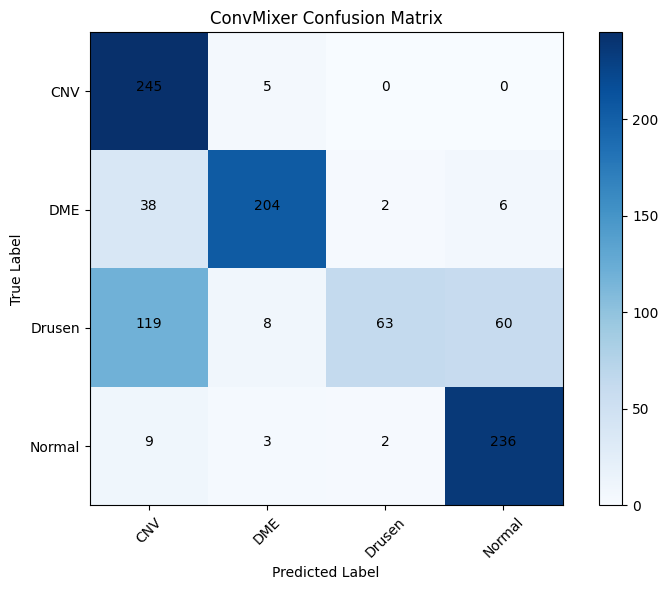

In [ ]:
cm_convmixer = confusion_matrix(

    y_true_convmixer,

    y_preds_convmixer

)


plt.figure(figsize=(8,6))

plt.imshow(

    cm_convmixer,

    cmap='Blues'

)

plt.title("ConvMixer Confusion Matrix")

plt.colorbar()


classes = [

    "CNV",

    "DME",

    "Drusen",

    "Normal"

]


tick_marks = np.arange(len(classes))


plt.xticks(

    tick_marks,

    classes,

    rotation=45

)


plt.yticks(

    tick_marks,

    classes

)


for i in range(cm_convmixer.shape[0]):

    for j in range(cm_convmixer.shape[1]):

        plt.text(

            j,

            i,

            format(cm_convmixer[i, j], 'd'),

            ha="center",

            color="black"

        )


plt.ylabel("True Label")

plt.xlabel("Predicted Label")

plt.tight_layout()

plt.show()

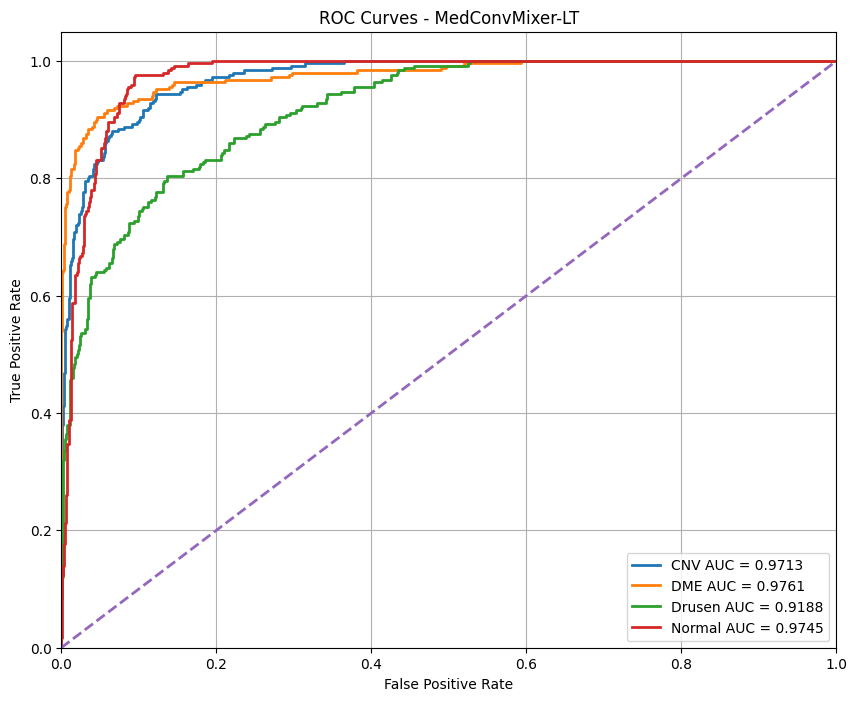

In [ ]:
from sklearn.metrics import (

    roc_curve,

    auc

)


y_true_bin_convmixer = label_binarize(

    y_true_convmixer,

    classes=[0,1,2,3]

)


class_names = [

    "CNV",

    "DME",

    "Drusen",

    "Normal"

]


fpr_convmixer = {}

tpr_convmixer = {}

roc_auc_convmixer = {}


for i in range(4):

    fpr_convmixer[i], tpr_convmixer[i], _ = roc_curve(

        y_true_bin_convmixer[:, i],

        np.array(y_probs_convmixer)[:, i]

    )

    roc_auc_convmixer[i] = auc(

        fpr_convmixer[i],

        tpr_convmixer[i]

    )


plt.figure(figsize=(10,8))


for i in range(4):

    plt.plot(

        fpr_convmixer[i],

        tpr_convmixer[i],

        lw=2,

        label=f"{class_names[i]} AUC = {roc_auc_convmixer[i]:.4f}"

    )


plt.plot(

    [0,1],

    [0,1],

    linestyle='--',

    lw=2

)


plt.xlim([0.0,1.0])

plt.ylim([0.0,1.05])

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curves - MedConvMixer-LT")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

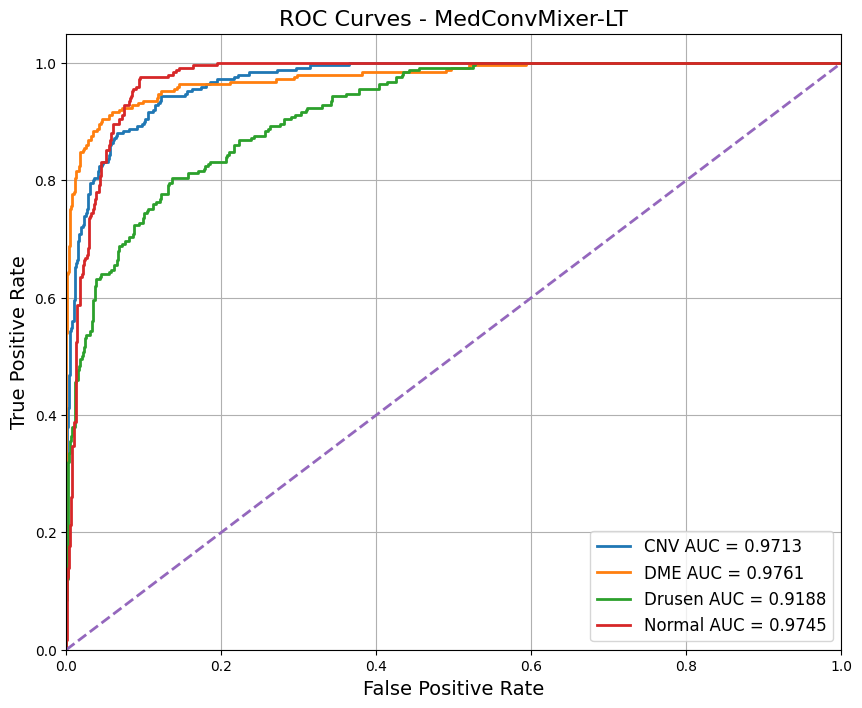

In [ ]:
plt.figure(figsize=(10,8))


for i in range(4):

    plt.plot(

        fpr_convmixer[i],

        tpr_convmixer[i],

        lw=2,

        label=f"{class_names[i]} AUC = {roc_auc_convmixer[i]:.4f}"

    )


plt.plot(

    [0,1],

    [0,1],

    linestyle='--',

    lw=2

)


plt.xlim([0.0,1.0])

plt.ylim([0.0,1.05])

plt.xlabel(

    "False Positive Rate",

    fontsize=14

)

plt.ylabel(

    "True Positive Rate",

    fontsize=14

)

plt.title(

    "ROC Curves - MedConvMixer-LT",

    fontsize=16

)

plt.legend(

    loc="lower right",

    fontsize=12

)

plt.grid(True)


plt.savefig(

    "convmixer_roc_curves.png",

    dpi=600,

    bbox_inches='tight'

)

plt.show()

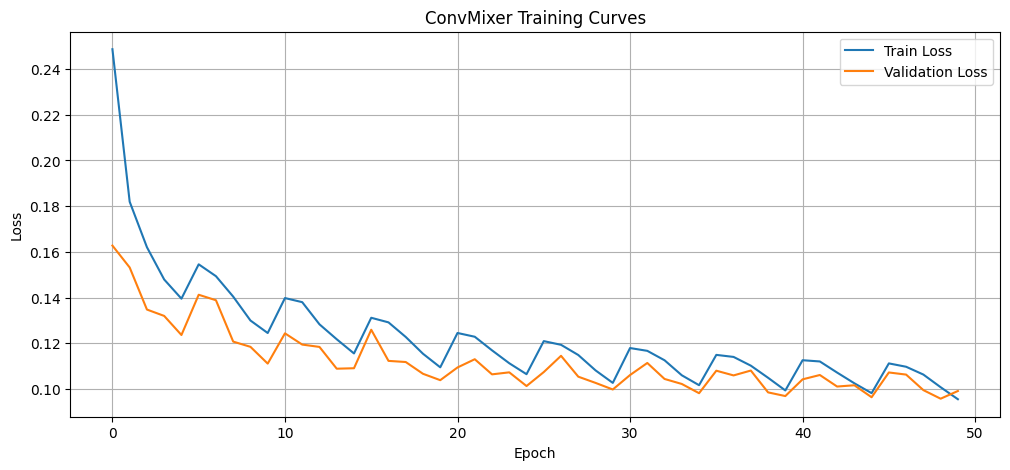

In [ ]:
plt.figure(figsize=(12,5))


plt.plot(

    history_convmixer["train_loss"],

    label="Train Loss"

)


plt.plot(

    history_convmixer["val_loss"],

    label="Validation Loss"

)


plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("ConvMixer Training Curves")

plt.legend()

plt.grid(True)

plt.show()

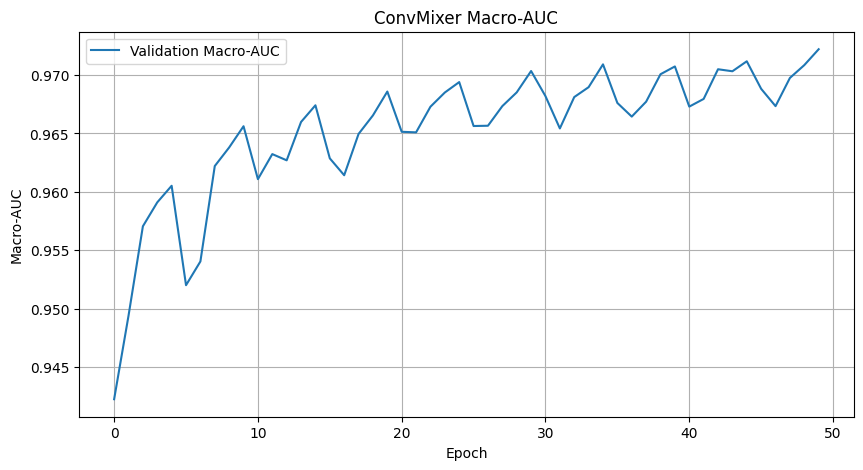

In [ ]:
plt.figure(figsize=(10,5))


plt.plot(

    history_convmixer["val_auc"],

    label="Validation Macro-AUC"

)


plt.xlabel("Epoch")

plt.ylabel("Macro-AUC")

plt.title("ConvMixer Macro-AUC")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
report_dict_convmixer = classification_report(

    y_true_convmixer,

    y_preds_convmixer,

    target_names=[

        "CNV",

        "DME",

        "Drusen",

        "Normal"

    ],

    output_dict=True

)


paper_table_convmixer = pd.DataFrame({

    "Class": [

        "CNV",

        "DME",

        "Drusen",

        "Normal"

    ],

    "Precision": [

        report_dict_convmixer["CNV"]["precision"],

        report_dict_convmixer["DME"]["precision"],

        report_dict_convmixer["Drusen"]["precision"],

        report_dict_convmixer["Normal"]["precision"]

    ],

    "Recall": [

        report_dict_convmixer["CNV"]["recall"],

        report_dict_convmixer["DME"]["recall"],

        report_dict_convmixer["Drusen"]["recall"],

        report_dict_convmixer["Normal"]["recall"]

    ],

    "F1-Score": [

        report_dict_convmixer["CNV"]["f1-score"],

        report_dict_convmixer["DME"]["f1-score"],

        report_dict_convmixer["Drusen"]["f1-score"],

        report_dict_convmixer["Normal"]["f1-score"]

    ],

    "AUC": [

        roc_auc_convmixer[0],

        roc_auc_convmixer[1],

        roc_auc_convmixer[2],

        roc_auc_convmixer[3]

    ]

})


paper_table_convmixer = paper_table_convmixer.round(4)

print(paper_table_convmixer)

    Class  Precision  Recall  F1-Score     AUC
0     CNV     0.5961   0.980    0.7413  0.9713
1     DME     0.9273   0.816    0.8681  0.9761
2  Drusen     0.9403   0.252    0.3975  0.9188
3  Normal     0.7815   0.944    0.8551  0.9745


EfficientNet-B0-CBAM-LT

In [ ]:
class SEBlock(nn.Module):

    def __init__(

        self,

        channels,

        reduction=4

    ):

        super().__init__()

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Sequential(

            nn.Linear(

                channels,

                channels // reduction

            ),

            nn.SiLU(),

            nn.Linear(

                channels // reduction,

                channels

            ),

            nn.Sigmoid()

        )

    def forward(self, x):

        b, c, _, _ = x.size()

        y = self.pool(x).view(b, c)

        y = self.fc(y).view(b, c, 1, 1)

        return x * y

In [ ]:
class ChannelAttention(nn.Module):

    def __init__(

        self,

        in_channels,

        reduction=8

    ):

        super().__init__()

        self.avg_pool = nn.AdaptiveAvgPool2d(1)

        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.shared = nn.Sequential(

            nn.Conv2d(

                in_channels,

                in_channels // reduction,

                1,

                bias=False

            ),

            nn.ReLU(),

            nn.Conv2d(

                in_channels // reduction,

                in_channels,

                1,

                bias=False

            )

        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        avg_out = self.shared(

            self.avg_pool(x)

        )

        max_out = self.shared(

            self.max_pool(x)

        )

        out = avg_out + max_out

        return self.sigmoid(out)

In [ ]:
class SpatialAttention(nn.Module):

    def __init__(

        self,

        kernel_size=7

    ):

        super().__init__()

        padding = kernel_size // 2

        self.conv = nn.Conv2d(

            2,

            1,

            kernel_size,

            padding=padding,

            bias=False

        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        avg_out = torch.mean(

            x,

            dim=1,

            keepdim=True

        )

        max_out, _ = torch.max(

            x,

            dim=1,

            keepdim=True

        )

        x = torch.cat(

            [avg_out, max_out],

            dim=1

        )

        x = self.conv(x)

        return self.sigmoid(x)

In [ ]:
class CBAM(nn.Module):

    def __init__(

        self,

        channels

    ):

        super().__init__()

        self.ca = ChannelAttention(

            channels

        )

        self.sa = SpatialAttention()

    def forward(self, x):

        x = x * self.ca(x)

        x = x * self.sa(x)

        return x

In [ ]:
class MBConvBlock(nn.Module):

    def __init__(

        self,

        in_channels,

        out_channels,

        expansion=4,

        stride=1

    ):

        super().__init__()

        hidden_dim = in_channels * expansion

        self.use_residual = (

            stride == 1

            and

            in_channels == out_channels

        )

        self.block = nn.Sequential(

            nn.Conv2d(

                in_channels,

                hidden_dim,

                kernel_size=1,

                bias=False

            ),

            nn.BatchNorm2d(hidden_dim),

            nn.SiLU(),

            nn.Conv2d(

                hidden_dim,

                hidden_dim,

                kernel_size=3,

                stride=stride,

                padding=1,

                groups=hidden_dim,

                bias=False

            ),

            nn.BatchNorm2d(hidden_dim),

            nn.SiLU(),

            SEBlock(hidden_dim),

            nn.Conv2d(

                hidden_dim,

                out_channels,

                kernel_size=1,

                bias=False

            ),

            nn.BatchNorm2d(out_channels)

        )

    def forward(self, x):

        out = self.block(x)

        if self.use_residual:

            out = out + x

        return out

In [ ]:
class EfficientNetB0CBAMLT(nn.Module):

    def __init__(

        self,

        num_classes=4

    ):

        super().__init__()

        self.stem = nn.Sequential(

            nn.Conv2d(

                1,

                32,

                kernel_size=3,

                stride=1,

                padding=1,

                bias=False

            ),

            nn.BatchNorm2d(32),

            nn.SiLU()

        )

        self.block1 = MBConvBlock(

            32,

            32,

            stride=1

        )

        self.cbam1 = CBAM(32)

        self.block2 = MBConvBlock(

            32,

            64,

            stride=2

        )

        self.cbam2 = CBAM(64)

        self.block3 = MBConvBlock(

            64,

            128,

            stride=2

        )

        self.cbam3 = CBAM(128)

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(

            128,

            num_classes

        )

    def forward(self, x):

        x = self.stem(x)

        x = self.block1(x)

        x = self.cbam1(x)

        x = self.block2(x)

        x = self.cbam2(x)

        x = self.block3(x)

        x = self.cbam3(x)

        x = self.pool(x)

        x = torch.flatten(x,1)

        x = self.dropout(x)

        x = self.fc(x)

        return x

In [ ]:
model_efficientnet = EfficientNetB0CBAMLT().to(device)

dummy = torch.randn(

    2,

    1,

    28,

    28

).to(device)

output = model_efficientnet(dummy)

print(output.shape)

torch.Size([2, 4])


In [ ]:
model_efficientnet = EfficientNetB0CBAMLT().to(device)

print("EfficientNet-B0-CBAM-LT initialized.")

EfficientNet-B0-CBAM-LT initialized.


In [ ]:
total_params_efficientnet = sum(

    p.numel()

    for p in model_efficientnet.parameters()

)


trainable_params_efficientnet = sum(

    p.numel()

    for p in model_efficientnet.parameters()

    if p.requires_grad

)


print(f"Total Parameters: {total_params_efficientnet:,}")

print(f"Trainable Parameters: {trainable_params_efficientnet:,}")

Total Parameters: 133,066
Trainable Parameters: 133,066


In [ ]:
optimizer_efficientnet = optim.AdamW(

    model_efficientnet.parameters(),

    lr=1e-3,

    weight_decay=1e-4

)


scheduler_efficientnet = CosineAnnealingWarmRestarts(

    optimizer_efficientnet,

    T_0=5

)


scaler_efficientnet = GradScaler()

print("Optimizer and AMP ready.")

Optimizer and AMP ready.


In [ ]:
best_val_loss_efficientnet = np.inf

patience_efficientnet = 7

counter_efficientnet = 0

In [ ]:
history_efficientnet = {

    "train_loss": [],

    "val_loss": [],

    "val_auc": [],

    "val_acc": []

}

In [ ]:
import os
import gc
import time
import numpy as np

EPOCHS = 50

CHECKPOINT_PATH = "efficientnet_checkpoint.pth"

BEST_MODEL_PATH = "best_efficientnet_model.pth"

start_epoch = 0


if os.path.exists(CHECKPOINT_PATH):

    print("\nCheckpoint found. Loading...")

    checkpoint = torch.load(

        CHECKPOINT_PATH,

        map_location=device,

        weights_only=False

    )

    model_efficientnet.load_state_dict(

        checkpoint["model_state_dict"]

    )

    optimizer_efficientnet.load_state_dict(

        checkpoint["optimizer_state_dict"]

    )

    scheduler_efficientnet.load_state_dict(

        checkpoint["scheduler_state_dict"]

    )

    scaler_efficientnet.load_state_dict(

        checkpoint["scaler_state_dict"]

    )

    history_efficientnet = checkpoint["history"]

    best_val_loss_efficientnet = checkpoint["best_val_loss"]

    counter_efficientnet = checkpoint["counter"]

    start_epoch = checkpoint["epoch"] + 1

    print(

        f"Resuming training from epoch {start_epoch}"

    )

else:

    print("\nStarting training from scratch.")


for epoch in range(start_epoch, EPOCHS):

    epoch_start = time.time()

    torch.cuda.empty_cache()

    gc.collect()

    model_efficientnet.train()

    train_loss = 0.0


    loop = tqdm(

        train_loader,

        total=len(train_loader),

        leave=True

    )


    for batch_idx, (images, labels) in enumerate(loop):

        images = images.to(device)

        labels = labels.to(device)

        optimizer_efficientnet.zero_grad(

            set_to_none=True

        )


        with autocast():

            outputs = model_efficientnet(images)

            loss = criterion(

                outputs,

                labels

            )


        scaler_efficientnet.scale(loss).backward()

        scaler_efficientnet.step(

            optimizer_efficientnet

        )

        scaler_efficientnet.update()

        train_loss += loss.item()


        current_lr = optimizer_efficientnet.param_groups[0]["lr"]


        loop.set_description(

            f"Epoch [{epoch+1}/{EPOCHS}]"

        )


        loop.set_postfix({

            "Loss": f"{loss.item():.4f}",

            "LR": f"{current_lr:.6f}"

        })


    train_loss /= len(train_loader)

    scheduler_efficientnet.step()


    model_efficientnet.eval()

    val_loss = 0.0

    y_true = []

    y_probs = []

    y_preds = []


    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.to(device)


            with autocast():

                outputs = model_efficientnet(images)

                loss = criterion(

                    outputs,

                    labels

                )

                probs = torch.softmax(

                    outputs,

                    dim=1

                )


            preds = torch.argmax(

                probs,

                dim=1

            )


            val_loss += loss.item()


            y_true.extend(

                labels.cpu().numpy()

            )


            y_probs.extend(

                probs.cpu().numpy()

            )


            y_preds.extend(

                preds.cpu().numpy()

            )


    val_loss /= len(val_loader)


    val_auc = compute_macro_auc(

        np.array(y_true),

        np.array(y_probs)

    )


    val_acc = accuracy_score(

        y_true,

        y_preds

    )


    history_efficientnet["train_loss"].append(

        train_loss

    )

    history_efficientnet["val_loss"].append(

        val_loss

    )

    history_efficientnet["val_auc"].append(

        val_auc

    )

    history_efficientnet["val_acc"].append(

        val_acc

    )


    epoch_time = time.time() - epoch_start


    print("\n" + "="*60)

    print(f"Epoch {epoch+1}/{EPOCHS}")

    print("="*60)

    print(f"Train Loss      : {train_loss:.4f}")

    print(f"Validation Loss : {val_loss:.4f}")

    print(f"Validation Acc  : {val_acc:.4f}")

    print(f"Validation AUC  : {val_auc:.4f}")

    print(f"Learning Rate   : {current_lr:.6f}")

    print(f"Epoch Time      : {epoch_time:.2f} sec")

    print("="*60)


    checkpoint = {

        "epoch": epoch,

        "model_state_dict": model_efficientnet.state_dict(),

        "optimizer_state_dict": optimizer_efficientnet.state_dict(),

        "scheduler_state_dict": scheduler_efficientnet.state_dict(),

        "scaler_state_dict": scaler_efficientnet.state_dict(),

        "history": history_efficientnet,

        "best_val_loss": best_val_loss_efficientnet,

        "counter": counter_efficientnet

    }


    torch.save(

        checkpoint,

        CHECKPOINT_PATH

    )


    print("Checkpoint saved successfully.")


    if val_loss < best_val_loss_efficientnet:

        best_val_loss_efficientnet = val_loss

        counter_efficientnet = 0


        torch.save(

            model_efficientnet.state_dict(),

            BEST_MODEL_PATH

        )


        print("Best EfficientNet model updated and saved.")

    else:

        counter_efficientnet += 1

        print(

            f"EarlyStopping Counter: {counter_efficientnet}"

        )


    if counter_efficientnet >= patience_efficientnet:

        print("\nEarly stopping triggered.")

        break


    torch.cuda.empty_cache()

    gc.collect()


Starting training from scratch.


Epoch [1/50]: 100%|██████████| 3047/3047 [00:55<00:00, 54.87it/s, Loss=1.0917, LR=0.001000]



Epoch 1/50
Train Loss      : 0.2380
Validation Loss : 0.1632
Validation Acc  : 0.8680
Validation AUC  : 0.9401
Learning Rate   : 0.001000
Epoch Time      : 58.27 sec
Checkpoint saved successfully.
Best EfficientNet model updated and saved.


Epoch [2/50]: 100%|██████████| 3047/3047 [00:52<00:00, 58.26it/s, Loss=0.2619, LR=0.000905]



Epoch 2/50
Train Loss      : 0.1659
Validation Loss : 0.1507
Validation Acc  : 0.8723
Validation AUC  : 0.9489
Learning Rate   : 0.000905
Epoch Time      : 54.46 sec
Checkpoint saved successfully.
Best EfficientNet model updated and saved.


...


Epoch 45/50
Train Loss      : 0.0679
Validation Loss : 0.0878
Validation Acc  : 0.9185
Validation AUC  : 0.9751
Learning Rate   : 0.000095
Epoch Time      : 54.54 sec
Checkpoint saved successfully.
EarlyStopping Counter: 5


Epoch [46/50]: 100%|██████████| 3047/3047 [00:52<00:00, 58.22it/s, Loss=0.3740, LR=0.001000]



Epoch 46/50
Train Loss      : 0.0861
Validation Loss : 0.1017
Validation Acc  : 0.9093
Validation AUC  : 0.9711
Learning Rate   : 0.001000
Epoch Time      : 54.56 sec
Checkpoint saved successfully.
EarlyStopping Counter: 6


Epoch [47/50]: 100%|██████████| 3047/3047 [00:52<00:00, 57.90it/s, Loss=0.0179, LR=0.000905]



Epoch 47/50
Train Loss      : 0.0833
Validation Loss : 0.0939
Validation Acc  : 0.9158
Validation AUC  : 0.9718
Learning Rate   : 0.000905
Epoch Time      : 54.93 sec
Checkpoint saved successfully.
EarlyStopping Counter: 7

Early stopping triggered.


In [ ]:
model_efficientnet.load_state_dict(

    torch.load(

        "best_efficientnet_model.pth",

        map_location=device,

        weights_only=False

    )

)

model_efficientnet.eval()

print("Best EfficientNet model loaded.")

Best EfficientNet model loaded.


In [ ]:
y_true_efficientnet = []

y_probs_efficientnet = []

y_preds_efficientnet = []


with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)


        with autocast():

            outputs = model_efficientnet(images)

            probs = torch.softmax(

                outputs,

                dim=1

            )


        preds = torch.argmax(

            probs,

            dim=1

        )


        y_true_efficientnet.extend(

            labels.numpy()

        )


        y_probs_efficientnet.extend(

            probs.cpu().numpy()

        )


        y_preds_efficientnet.extend(

            preds.cpu().numpy()

        )

In [ ]:
from sklearn.metrics import (

    classification_report,

    precision_score,

    recall_score,

    f1_score

)


test_acc_efficientnet = accuracy_score(

    y_true_efficientnet,

    y_preds_efficientnet

)


test_auc_efficientnet = compute_macro_auc(

    np.array(y_true_efficientnet),

    np.array(y_probs_efficientnet)

)


macro_precision_efficientnet = precision_score(

    y_true_efficientnet,

    y_preds_efficientnet,

    average='macro'

)


macro_recall_efficientnet = recall_score(

    y_true_efficientnet,

    y_preds_efficientnet,

    average='macro'

)


macro_f1_efficientnet = f1_score(

    y_true_efficientnet,

    y_preds_efficientnet,

    average='macro'

)


print("\n========== EFFICIENTNET RESULTS ==========\n")

print(f"Accuracy        : {test_acc_efficientnet:.4f}")

print(f"Macro-AUC       : {test_auc_efficientnet:.4f}")

print(f"Macro Precision : {macro_precision_efficientnet:.4f}")

print(f"Macro Recall    : {macro_recall_efficientnet:.4f}")

print(f"Macro F1-Score  : {macro_f1_efficientnet:.4f}")


========== EFFICIENTNET RESULTS ==========

Accuracy        : 0.7860
Macro-AUC       : 0.9637
Macro Precision : 0.8346
Macro Recall    : 0.7860
Macro F1-Score  : 0.7644


In [ ]:
report_efficientnet = classification_report(

    y_true_efficientnet,

    y_preds_efficientnet,

    target_names=[

        "CNV",

        "DME",

        "Drusen",

        "Normal"

    ]

)


print(report_efficientnet)

              precision    recall  f1-score   support

         CNV       0.64      0.98      0.78       250
         DME       0.96      0.84      0.90       250
      Drusen       0.95      0.35      0.51       250
      Normal       0.79      0.97      0.87       250

    accuracy                           0.79      1000
   macro avg       0.83      0.79      0.76      1000
weighted avg       0.83      0.79      0.76      1000



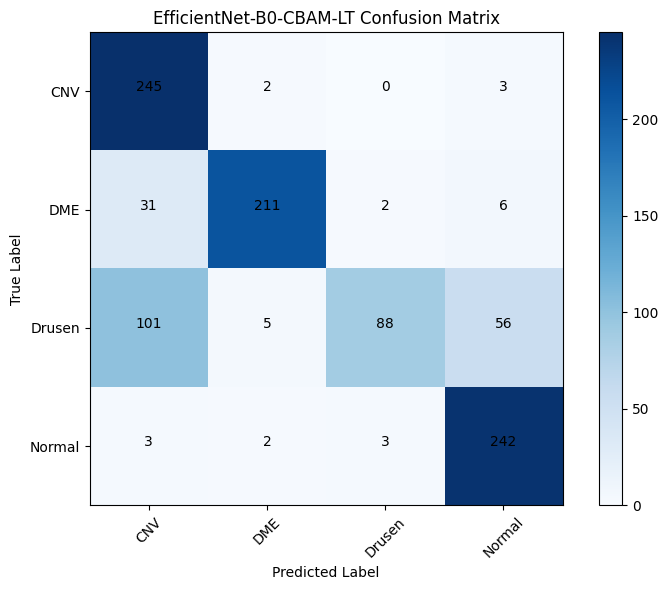

In [ ]:
cm_efficientnet = confusion_matrix(

    y_true_efficientnet,

    y_preds_efficientnet

)


plt.figure(figsize=(8,6))

plt.imshow(

    cm_efficientnet,

    cmap='Blues'

)

plt.title("EfficientNet-B0-CBAM-LT Confusion Matrix")

plt.colorbar()


classes = [

    "CNV",

    "DME",

    "Drusen",

    "Normal"

]


tick_marks = np.arange(len(classes))


plt.xticks(

    tick_marks,

    classes,

    rotation=45

)


plt.yticks(

    tick_marks,

    classes

)


for i in range(cm_efficientnet.shape[0]):

    for j in range(cm_efficientnet.shape[1]):

        plt.text(

            j,

            i,

            format(cm_efficientnet[i, j], 'd'),

            ha="center",

            color="black"

        )


plt.ylabel("True Label")

plt.xlabel("Predicted Label")

plt.tight_layout()

plt.show()

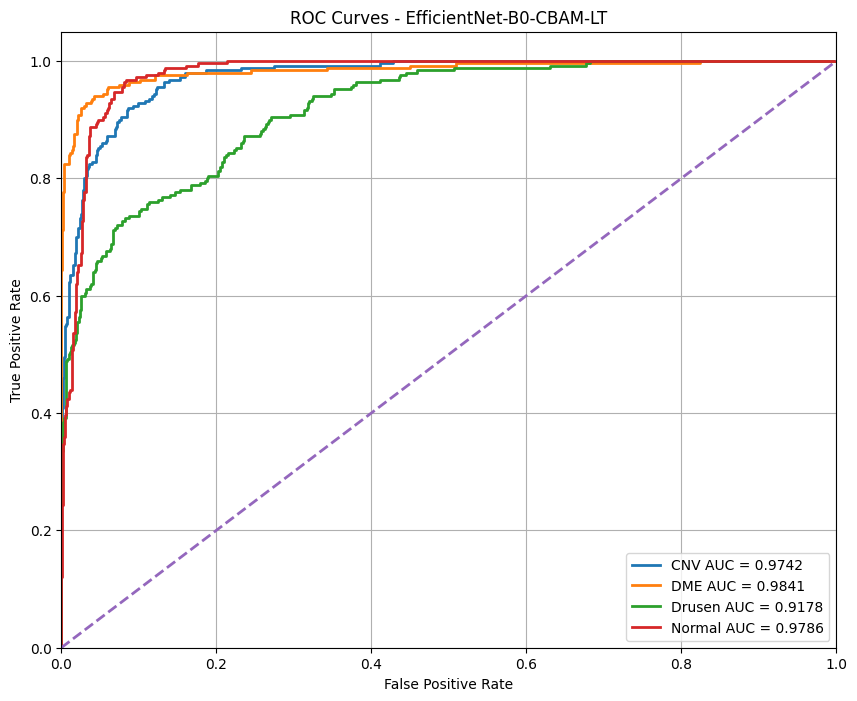

In [ ]:
from sklearn.metrics import (

    roc_curve,

    auc

)


y_true_bin_efficientnet = label_binarize(

    y_true_efficientnet,

    classes=[0,1,2,3]

)


class_names = [

    "CNV",

    "DME",

    "Drusen",

    "Normal"

]


fpr_efficientnet = {}

tpr_efficientnet = {}

roc_auc_efficientnet = {}


for i in range(4):

    fpr_efficientnet[i], tpr_efficientnet[i], _ = roc_curve(

        y_true_bin_efficientnet[:, i],

        np.array(y_probs_efficientnet)[:, i]

    )

    roc_auc_efficientnet[i] = auc(

        fpr_efficientnet[i],

        tpr_efficientnet[i]

    )


plt.figure(figsize=(10,8))


for i in range(4):

    plt.plot(

        fpr_efficientnet[i],

        tpr_efficientnet[i],

        lw=2,

        label=f"{class_names[i]} AUC = {roc_auc_efficientnet[i]:.4f}"

    )


plt.plot(

    [0,1],

    [0,1],

    linestyle='--',

    lw=2

)


plt.xlim([0.0,1.0])

plt.ylim([0.0,1.05])

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curves - EfficientNet-B0-CBAM-LT")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

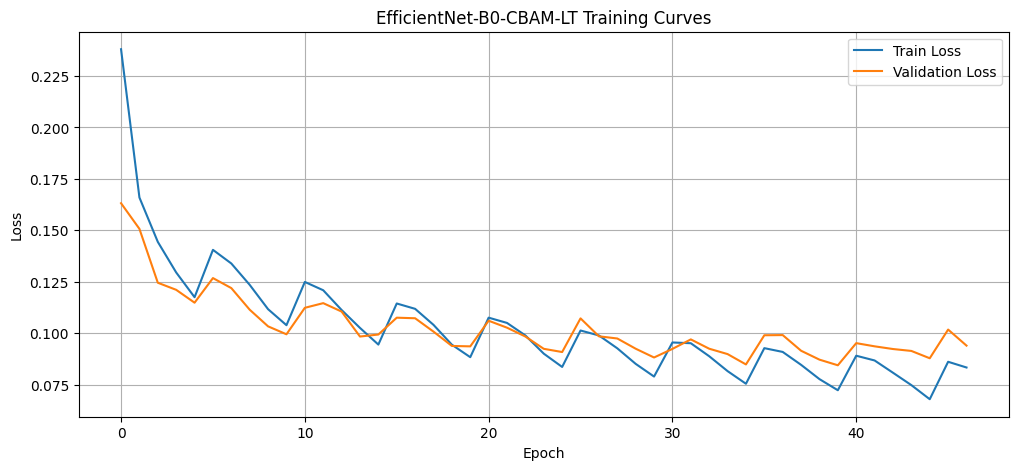

In [ ]:
plt.figure(figsize=(12,5))


plt.plot(

    history_efficientnet["train_loss"],

    label="Train Loss"

)


plt.plot(

    history_efficientnet["val_loss"],

    label="Validation Loss"

)


plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("EfficientNet-B0-CBAM-LT Training Curves")

plt.legend()

plt.grid(True)

plt.show()

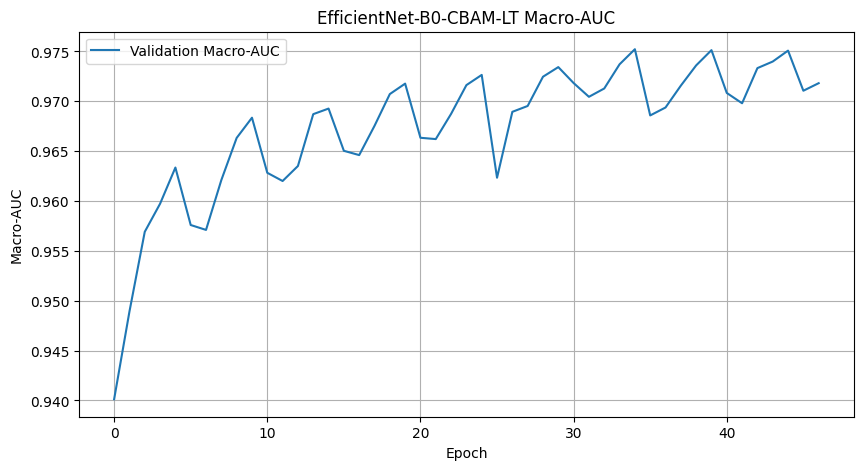

In [ ]:
plt.figure(figsize=(10,5))


plt.plot(

    history_efficientnet["val_auc"],

    label="Validation Macro-AUC"

)


plt.xlabel("Epoch")

plt.ylabel("Macro-AUC")

plt.title("EfficientNet-B0-CBAM-LT Macro-AUC")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
report_dict_efficientnet = classification_report(

    y_true_efficientnet,

    y_preds_efficientnet,

    target_names=[

        "CNV",

        "DME",

        "Drusen",

        "Normal"

    ],

    output_dict=True

)


paper_table_efficientnet = pd.DataFrame({

    "Class": [

        "CNV",

        "DME",

        "Drusen",

        "Normal"

    ],

    "Precision": [

        report_dict_efficientnet["CNV"]["precision"],

        report_dict_efficientnet["DME"]["precision"],

        report_dict_efficientnet["Drusen"]["precision"],

        report_dict_efficientnet["Normal"]["precision"]

    ],

    "Recall": [

        report_dict_efficientnet["CNV"]["recall"],

        report_dict_efficientnet["DME"]["recall"],

        report_dict_efficientnet["Drusen"]["recall"],

        report_dict_efficientnet["Normal"]["recall"]

    ],

    "F1-Score": [

        report_dict_efficientnet["CNV"]["f1-score"],

        report_dict_efficientnet["DME"]["f1-score"],

        report_dict_efficientnet["Drusen"]["f1-score"],

        report_dict_efficientnet["Normal"]["f1-score"]

    ],

    "AUC": [

        roc_auc_efficientnet[0],

        roc_auc_efficientnet[1],

        roc_auc_efficientnet[2],

        roc_auc_efficientnet[3]

    ]

})


paper_table_efficientnet = paper_table_efficientnet.round(4)

print(paper_table_efficientnet)

    Class  Precision  Recall  F1-Score     AUC
0     CNV     0.6447   0.980    0.7778  0.9742
1     DME     0.9591   0.844    0.8979  0.9841
2  Drusen     0.9462   0.352    0.5131  0.9178
3  Normal     0.7883   0.968    0.8689  0.9786


ResNet18 baseline

In [ ]:
import os
import gc
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from tqdm import tqdm

from torchvision.models import resnet18

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.preprocessing import label_binarize

from torch.cuda.amp import (
    autocast,
    GradScaler
)

from torch.optim.lr_scheduler import (
    CosineAnnealingLR
)

warnings.filterwarnings("ignore")


device=torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"

)

print(device)

cuda


In [ ]:
class FocalLoss(nn.Module):

    def __init__(

        self,

        alpha=1,

        gamma=2

    ):

        super().__init__()

        self.alpha=alpha

        self.gamma=gamma


    def forward(

        self,

        inputs,

        targets

    ):


        ce=F.cross_entropy(

            inputs,

            targets,

            reduction='none',

            label_smoothing=0.1


        )


        pt=torch.exp(-ce)


        loss=(

            self.alpha*

            ((1-pt)**self.gamma)*

            ce

        )


        return loss.mean()


criterion=FocalLoss()

In [ ]:
def compute_macro_auc(

    y_true,

    y_probs,

    num_classes=4

):


    y_true_bin=label_binarize(

        y_true,

        classes=list(

            range(num_classes)

        )

    )


    return roc_auc_score(

        y_true_bin,

        y_probs,

        average='macro',

        multi_class='ovr'

    )

In [ ]:
class OCTResNet18(nn.Module):

    def __init__(

        self,

        num_classes=4

    ):

        super().__init__()


        self.model=resnet18(

            weights=None

        )


        self.model.conv1=nn.Conv2d(

            1,

            64,

            kernel_size=3,

            stride=1,

            padding=1,

            bias=False

        )


        self.model.maxpool=nn.Identity()


        self.model.fc=nn.Sequential(

            nn.Dropout(

                0.2

            ),

            nn.Linear(

                512,

                num_classes

            )

        )


    def forward(

        self,

        x

    ):

        return self.model(x)

In [ ]:
model_resnet=OCTResNet18().to(device)

dummy=torch.randn(

    2,

    1,

    28,

    28

).to(device)


out=model_resnet(dummy)

print(out.shape)

torch.Size([2, 4])


In [ ]:
params=sum(

    p.numel()

    for p in model_resnet.parameters()

)

print(

    f"Parameters: {params:,}"

)

Parameters: 11,169,732


In [ ]:
optimizer_resnet=optim.AdamW(

    model_resnet.parameters(),

    lr=7e-4,

    weight_decay=1e-4

)


scheduler_resnet=CosineAnnealingLR(

    optimizer_resnet,

    T_max=50,

    eta_min=1e-6

)


scaler_resnet=GradScaler()

In [ ]:
best_val_loss_resnet=np.inf

patience_resnet=7

counter_resnet=0


history_resnet={

    "train_loss":[],

    "val_loss":[],

    "val_auc":[],

    "val_acc":[]

}

In [ ]:
CHECKPOINT_PATH="resnet_checkpoint.pth"

BEST_MODEL_PATH="best_resnet_model.pth"

In [ ]:
if os.path.exists(

    CHECKPOINT_PATH

):

    os.remove(

        CHECKPOINT_PATH

    )


if os.path.exists(

    BEST_MODEL_PATH

):

    os.remove(

        BEST_MODEL_PATH

    )


print(

    "Checkpoints resetados"

)

Checkpoints resetados


In [ ]:
import os
import gc
import time
import numpy as np

EPOCHS=50

start_epoch=0


if os.path.exists(

    CHECKPOINT_PATH

):

    print(

        "\nCheckpoint encontrado"

    )


    checkpoint=torch.load(

        CHECKPOINT_PATH,

        map_location=device,

        weights_only=False

    )


    model_resnet.load_state_dict(

        checkpoint["model_state_dict"]

    )


    optimizer_resnet.load_state_dict(

        checkpoint["optimizer_state_dict"]

    )


    scheduler_resnet.load_state_dict(

        checkpoint["scheduler_state_dict"]

    )


    scaler_resnet.load_state_dict(

        checkpoint["scaler_state_dict"]

    )


    history_resnet=checkpoint["history"]


    best_val_loss_resnet=checkpoint["best_val_loss"]


    counter_resnet=checkpoint["counter"]


    start_epoch=checkpoint["epoch"]+1


    print(

        f"Retomando época {start_epoch}"

    )


else:


    history_resnet={

        "train_loss":[],

        "val_loss":[],

        "val_auc":[],

        "val_acc":[]

    }


    best_val_loss_resnet=np.inf


    counter_resnet=0


    print(

        "\nTreino iniciado do zero"

    )


for epoch in range(

    start_epoch,

    EPOCHS

):


    epoch_start=time.time()


    torch.cuda.empty_cache()

    gc.collect()


    model_resnet.train()


    train_loss=0


    loop=tqdm(

        train_loader,

        total=len(train_loader),

        leave=True

    )


    for images,labels in loop:


        images=images.to(device)

        labels=labels.to(device)


        optimizer_resnet.zero_grad(

            set_to_none=True

        )


        with autocast():

            outputs=model_resnet(

                images

            )


            loss=criterion(

                outputs,

                labels

            )


        scaler_resnet.scale(

            loss

        ).backward()


        torch.nn.utils.clip_grad_norm_(

            model_resnet.parameters(),

            1.0

        )


        scaler_resnet.step(

            optimizer_resnet

        )


        scaler_resnet.update()


        train_loss+=loss.item()


        current_lr=optimizer_resnet.param_groups[0]["lr"]


        loop.set_description(

            f"Epoch [{epoch+1}/{EPOCHS}]"

        )


        loop.set_postfix({

            "loss":

            f"{loss.item():.4f}",

            "lr":

            f"{current_lr:.6f}"

        })


    train_loss/=len(

        train_loader

    )


    scheduler_resnet.step()


    model_resnet.eval()


    val_loss=0


    y_true=[]

    y_probs=[]

    y_preds=[]


    with torch.no_grad():

        for images,labels in val_loader:


            images=images.to(device)

            labels=labels.to(device)


            with autocast():

                outputs=model_resnet(

                    images

                )


                loss=criterion(

                    outputs,

                    labels

                )


                probs=torch.softmax(

                    outputs,

                    dim=1

                )


            preds=torch.argmax(

                probs,

                dim=1

            )


            val_loss+=loss.item()


            y_true.extend(

                labels.cpu().numpy()

            )


            y_probs.extend(

                probs.cpu().numpy()

            )


            y_preds.extend(

                preds.cpu().numpy()

            )


    val_loss/=len(

        val_loader

    )


    val_auc=compute_macro_auc(

        np.array(y_true),

        np.array(y_probs)

    )


    val_acc=accuracy_score(

        y_true,

        y_preds

    )


    history_resnet[

        "train_loss"

    ].append(

        train_loss

    )


    history_resnet[

        "val_loss"

    ].append(

        val_loss

    )


    history_resnet[

        "val_auc"

    ].append(

        val_auc

    )


    history_resnet[

        "val_acc"

    ].append(

        val_acc

    )


    epoch_time=time.time()-epoch_start


    print("\n"+"="*60)

    print(

        f"Epoch {epoch+1}/{EPOCHS}"

    )

    print("="*60)

    print(

        f"Train Loss : {train_loss:.4f}"

    )

    print(

        f"Val Loss   : {val_loss:.4f}"

    )

    print(

        f"Val Acc    : {val_acc:.4f}"

    )

    print(

        f"Val AUC    : {val_auc:.4f}"

    )

    print(

        f"LR         : {current_lr:.6f}"

    )

    print(

        f"Time       : {epoch_time:.2f}s"

    )

    print("="*60)


    checkpoint={

        "epoch":epoch,

        "model_state_dict":

        model_resnet.state_dict(),

        "optimizer_state_dict":

        optimizer_resnet.state_dict(),

        "scheduler_state_dict":

        scheduler_resnet.state_dict(),

        "scaler_state_dict":

        scaler_resnet.state_dict(),

        "history":

        history_resnet,

        "best_val_loss":

        best_val_loss_resnet,

        "counter":

        counter_resnet

    }


    torch.save(

        checkpoint,

        CHECKPOINT_PATH

    )


    print(

        "Checkpoint salvo"

    )


    if val_loss<best_val_loss_resnet:


        best_val_loss_resnet=val_loss


        counter_resnet=0


        torch.save(

            model_resnet.state_dict(),

            BEST_MODEL_PATH

        )


        print(

            "Melhor modelo salvo"

        )


    else:


        counter_resnet+=1


        print(

            f"EarlyStopping Counter: {counter_resnet}"

        )


    if counter_resnet>=patience_resnet:


        print(

            "\nEarly stopping"

        )

        break


    torch.cuda.empty_cache()

    gc.collect()


Treino iniciado do zero


Epoch [1/50]: 100%|██████████| 3047/3047 [00:56<00:00, 53.50it/s, loss=0.0687, lr=0.000700]



Epoch 1/50
Train Loss : 0.2628
Val Loss   : 0.1547
Val Acc    : 0.8714
Val AUC    : 0.9486
LR         : 0.000700
Time       : 58.94s
Checkpoint salvo
Melhor modelo salvo


Epoch [2/50]: 100%|██████████| 3047/3047 [00:56<00:00, 54.21it/s, loss=0.0161, lr=0.000699]



Epoch 2/50
Train Loss : 0.1515
Val Loss   : 0.1418
Val Acc    : 0.8780
Val AUC    : 0.9572
LR         : 0.000699
Time       : 58.12s
Checkpoint salvo
Melhor modelo salvo


...


Epoch 21/50
Train Loss : 0.0745
Val Loss   : 0.0968
Val Acc    : 0.9190
Val AUC    : 0.9756
LR         : 0.000459
Time       : 58.34s
Checkpoint salvo
EarlyStopping Counter: 5


Epoch [22/50]: 100%|██████████| 3047/3047 [00:56<00:00, 54.31it/s, loss=3.3240, lr=0.000437]



Epoch 22/50
Train Loss : 0.0713
Val Loss   : 0.0933
Val Acc    : 0.9258
Val AUC    : 0.9765
LR         : 0.000437
Time       : 58.18s
Checkpoint salvo
EarlyStopping Counter: 6


Epoch [23/50]: 100%|██████████| 3047/3047 [00:56<00:00, 54.30it/s, loss=0.0101, lr=0.000416]



Epoch 23/50
Train Loss : 0.0733
Val Loss   : 0.0913
Val Acc    : 0.9246
Val AUC    : 0.9769
LR         : 0.000416
Time       : 58.07s
Checkpoint salvo
EarlyStopping Counter: 7

Early stopping


In [ ]:
model_resnet.load_state_dict(

    torch.load(

        BEST_MODEL_PATH,

        map_location=device,

        weights_only=False

    )

)

model_resnet.eval()

print(

    "Best ResNet loaded."

)

Best ResNet loaded.


In [ ]:
y_true_resnet=[]

y_probs_resnet=[]

y_preds_resnet=[]


with torch.no_grad():

    for images,labels in test_loader:


        images=images.to(device)


        with autocast():

            outputs=model_resnet(

                images

            )


            probs=torch.softmax(

                outputs,

                dim=1

            )


        preds=torch.argmax(

            probs,

            dim=1

        )


        y_true_resnet.extend(

            labels.numpy()

        )


        y_probs_resnet.extend(

            probs.cpu().numpy()

        )


        y_preds_resnet.extend(

            preds.cpu().numpy()

        )

In [ ]:
test_acc_resnet=accuracy_score(

    y_true_resnet,

    y_preds_resnet

)


test_auc_resnet=compute_macro_auc(

    np.array(y_true_resnet),

    np.array(y_probs_resnet)

)


precision_resnet=precision_score(

    y_true_resnet,

    y_preds_resnet,

    average='macro'

)


recall_resnet=recall_score(

    y_true_resnet,

    y_preds_resnet,

    average='macro'

)


f1_resnet=f1_score(

    y_true_resnet,

    y_preds_resnet,

    average='macro'

)


print(

"\n========== RESNET18 RESULTS ==========\n"

)

print(

f"Accuracy: {test_acc_resnet:.4f}"

)

print(

f"Macro AUC: {test_auc_resnet:.4f}"

)

print(

f"Precision: {precision_resnet:.4f}"

)

print(

f"Recall: {recall_resnet:.4f}"

)

print(

f"F1: {f1_resnet:.4f}"

)


========== RESNET18 RESULTS ==========

Accuracy: 0.7360
Macro AUC: 0.9556
Precision: 0.8105
Recall: 0.7360
F1: 0.7085


In [ ]:
report_resnet=classification_report(

    y_true_resnet,

    y_preds_resnet,

    target_names=[

        "CNV",

        "DME",

        "Drusen",

        "Normal"

    ]

)


print(

    report_resnet

)

              precision    recall  f1-score   support

         CNV       0.55      0.99      0.71       250
         DME       0.97      0.78      0.87       250
      Drusen       0.90      0.25      0.39       250
      Normal       0.83      0.92      0.87       250

    accuracy                           0.74      1000
   macro avg       0.81      0.74      0.71      1000
weighted avg       0.81      0.74      0.71      1000



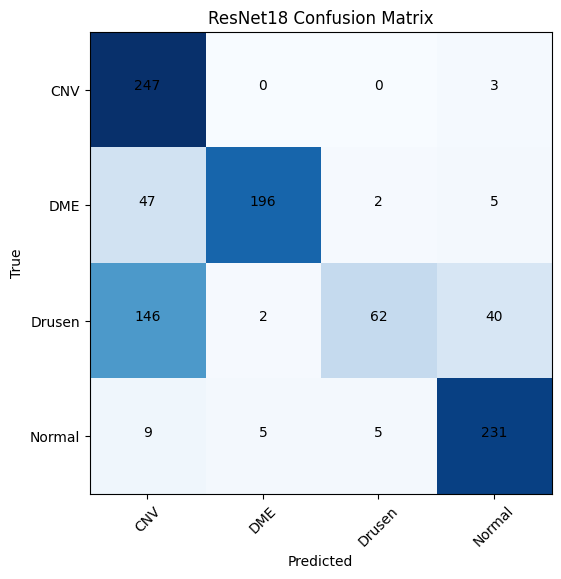

In [ ]:
cm=confusion_matrix(

    y_true_resnet,

    y_preds_resnet

)


plt.figure(

    figsize=(8,6)

)


plt.imshow(

    cm,

    cmap='Blues'

)


classes=[

    "CNV",

    "DME",

    "Drusen",

    "Normal"

]


ticks=np.arange(

    len(classes)

)


plt.xticks(

    ticks,

    classes,

    rotation=45

)


plt.yticks(

    ticks,

    classes

)


for i in range(

    cm.shape[0]

):

    for j in range(

        cm.shape[1]

    ):

        plt.text(

            j,

            i,

            cm[i,j],

            ha='center'

        )


plt.title(

    "ResNet18 Confusion Matrix"

)

plt.ylabel(

    "True"

)

plt.xlabel(

    "Predicted"

)

plt.show()

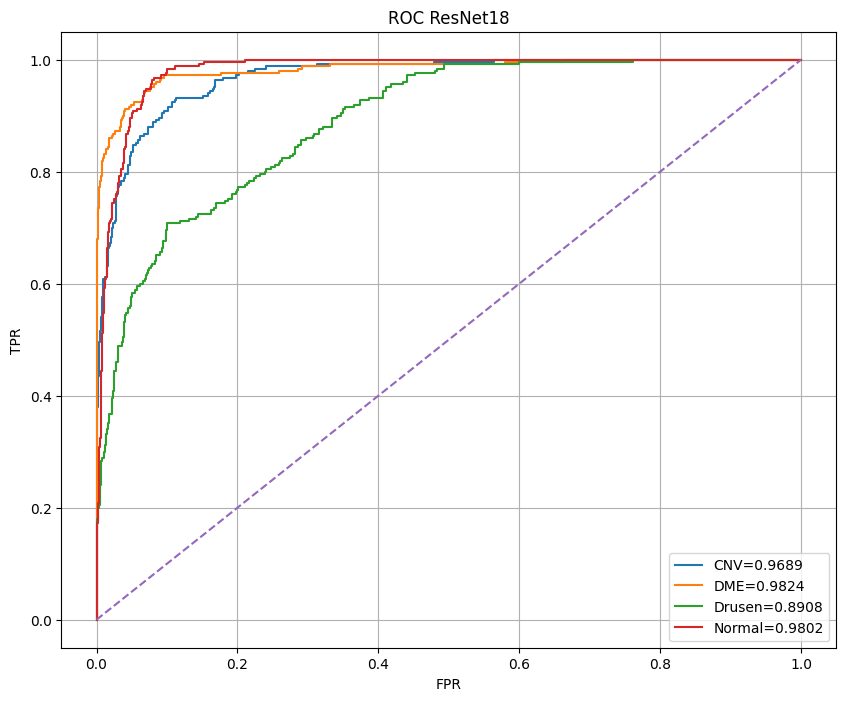

In [ ]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc


y_true_bin=label_binarize(

    y_true_resnet,

    classes=[0,1,2,3]

)


names=[

    "CNV",

    "DME",

    "Drusen",

    "Normal"

]


plt.figure(

    figsize=(10,8)

)


for i in range(4):


    fpr,tpr,_=roc_curve(

        y_true_bin[:,i],

        np.array(

            y_probs_resnet

        )[:,i]

    )


    roc_auc=auc(

        fpr,

        tpr

    )


    plt.plot(

        fpr,

        tpr,

        label=f"{names[i]}={roc_auc:.4f}"

    )


plt.plot(

    [0,1],

    [0,1],

    linestyle='--'

)


plt.legend()

plt.grid()

plt.xlabel(

    "FPR"

)

plt.ylabel(

    "TPR"

)

plt.title(

    "ROC ResNet18"

)

plt.show()

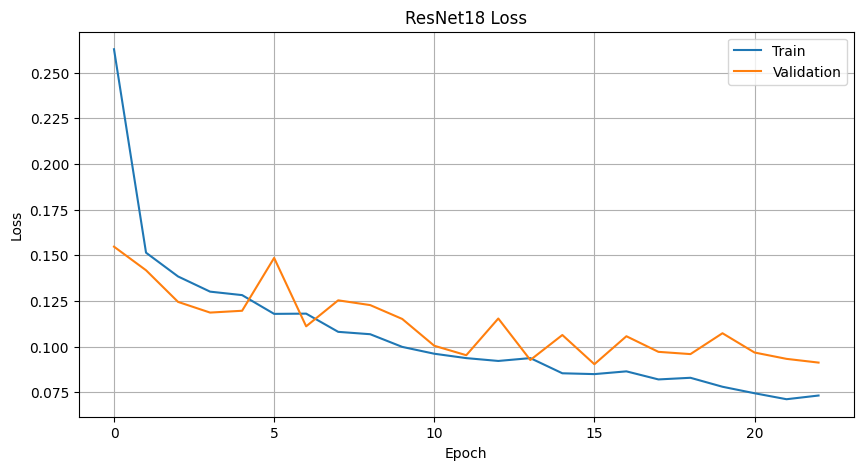

In [ ]:
plt.figure(

    figsize=(10,5)

)


plt.plot(

    history_resnet[

        "train_loss"

    ],

    label='Train'

)


plt.plot(

    history_resnet[

        "val_loss"

    ],

    label='Validation'

)


plt.legend()

plt.grid()

plt.xlabel(

    "Epoch"

)

plt.ylabel(

    "Loss"

)

plt.title(

    "ResNet18 Loss"

)

plt.show()

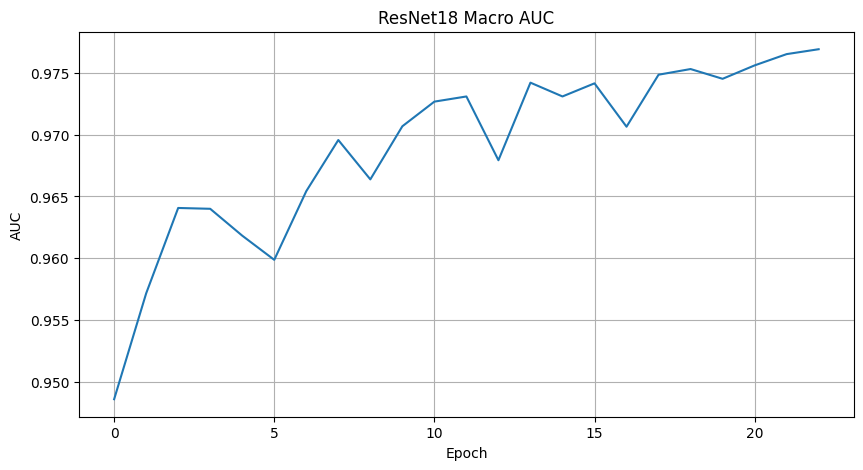

In [ ]:
plt.figure(

    figsize=(10,5)

)


plt.plot(

    history_resnet[

        "val_auc"

    ]

)


plt.grid()

plt.xlabel(

    "Epoch"

)

plt.ylabel(

    "AUC"

)

plt.title(

    "ResNet18 Macro AUC"

)

plt.show()

In [ ]:
report_dict=classification_report(

    y_true_resnet,

    y_preds_resnet,

    output_dict=True,

    target_names=[

        "CNV",

        "DME",

        "Drusen",

        "Normal"

    ]

)


paper_resnet=pd.DataFrame({

    "Class":[

        "CNV",

        "DME",

        "Drusen",

        "Normal"

    ],

    "Precision":[

        report_dict["CNV"]["precision"],

        report_dict["DME"]["precision"],

        report_dict["Drusen"]["precision"],

        report_dict["Normal"]["precision"]

    ],

    "Recall":[

        report_dict["CNV"]["recall"],

        report_dict["DME"]["recall"],

        report_dict["Drusen"]["recall"],

        report_dict["Normal"]["recall"]

    ],

    "F1":[

        report_dict["CNV"]["f1-score"],

        report_dict["DME"]["f1-score"],

        report_dict["Drusen"]["f1-score"],

        report_dict["Normal"]["f1-score"]

    ]

})


paper_resnet=paper_resnet.round(4)

print(

    paper_resnet

)

    Class  Precision  Recall      F1
0     CNV     0.5501   0.988  0.7067
1     DME     0.9655   0.784  0.8653
2  Drusen     0.8986   0.248  0.3887
3  Normal     0.8280   0.924  0.8733


TinyViT-LT

In [ ]:
import os
import gc
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.preprocessing import label_binarize

from torch.cuda.amp import (
    autocast,
    GradScaler
)

from torch.optim.lr_scheduler import (
    CosineAnnealingLR
)

warnings.filterwarnings("ignore")

device=torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [ ]:
class FocalLoss(nn.Module):

    def __init__(
        self,
        alpha=.75,
        gamma=1.5
    ):

        super().__init__()

        self.alpha=alpha
        self.gamma=gamma


    def forward(
        self,
        inputs,
        targets
    ):

        ce=F.cross_entropy(
            inputs,
            targets,
            reduction='none',
            label_smoothing=0.1
        )

        pt=torch.exp(-ce)

        loss=(
            self.alpha*
            ((1-pt)**self.gamma)*
            ce
        )

        return loss.mean()


criterion=FocalLoss()

In [ ]:
def compute_macro_auc(

    y_true,

    y_probs,

    num_classes=4

):

    y_true_bin=label_binarize(

        y_true,

        classes=list(
            range(num_classes)
        )

    )


    return roc_auc_score(

        y_true_bin,

        y_probs,

        average='macro',

        multi_class='ovr'

    )

In [ ]:
class PatchEmbedding(nn.Module):

    def __init__(

        self,

        in_channels=1,

        embed_dim=96

    ):

        super().__init__()


        self.proj=nn.Sequential(

            nn.Conv2d(

                in_channels,

                embed_dim,

                kernel_size=3,

                stride=2,

                padding=1

            ),

            nn.BatchNorm2d(

                embed_dim

            ),

            nn.GELU()

        )


    def forward(self,x):

        x=self.proj(x)

        return x

In [ ]:
class TinyBlock(nn.Module):

    def __init__(

        self,

        dim,

        heads=4,

        mlp_ratio=4

    ):

        super().__init__()


        self.norm1=nn.LayerNorm(dim)


        self.attn=nn.MultiheadAttention(

            dim,

            heads,

            batch_first=True

        )


        self.norm2=nn.LayerNorm(dim)


        self.mlp=nn.Sequential(

            nn.Linear(

                dim,

                dim*mlp_ratio

            ),

            nn.GELU(),

            nn.Linear(

                dim*mlp_ratio,

                dim

            )

        )


    def forward(self,x):


        residual=x


        x=self.norm1(x)


        x,_=self.attn(

            x,

            x,

            x

        )


        x=x+residual


        residual=x


        x=self.norm2(x)


        x=self.mlp(x)


        x=x+residual


        return x

In [ ]:
class TinyViTLT(nn.Module):

    def __init__(

        self,

        num_classes=4,

        embed_dim=96,

        depth=4

    ):

        super().__init__()


        self.patch=PatchEmbedding(

            1,

            embed_dim

        )


        self.blocks=nn.Sequential(

            *[

                TinyBlock(

                    embed_dim

                )

                for _ in range(depth)

            ]

        )


        self.pool=nn.AdaptiveAvgPool1d(1)


        self.dropout=nn.Dropout(

            0.2

        )


        self.fc=nn.Linear(

            embed_dim,

            num_classes

        )


    def forward(self,x):


        x=self.patch(x)


        B,C,H,W=x.shape


        x=x.flatten(2)


        x=x.transpose(1,2)


        x=self.blocks(x)


        x=x.transpose(1,2)


        x=self.pool(x)


        x=x.squeeze(-1)


        x=self.dropout(x)


        x=self.fc(x)


        return x

In [ ]:
model_tinyvit=TinyViTLT().to(device)

dummy=torch.randn(

    2,

    1,

    28,

    28

).to(device)


out=model_tinyvit(dummy)

print(out.shape)

torch.Size([2, 4])


In [ ]:
params=sum(

    p.numel()

    for p in model_tinyvit.parameters()

)

print(

    f"Parameters: {params:,}"

)

Parameters: 448,900


In [ ]:
optimizer_tinyvit=optim.AdamW(

    model_tinyvit.parameters(),

    lr=7e-4,

    weight_decay=1e-4

)


scheduler_tinyvit=CosineAnnealingLR(

    optimizer_tinyvit,

    T_max=50,

    eta_min=1e-6

)


scaler_tinyvit=GradScaler()

In [ ]:
best_val_loss_tinyvit=np.inf

patience_tinyvit=7

counter_tinyvit=0


history_tinyvit={

    "train_loss":[],

    "val_loss":[],

    "val_auc":[],

    "val_acc":[]

}

In [ ]:
CHECKPOINT_PATH="tinyvit_checkpoint.pth"

BEST_MODEL_PATH="best_tinyvit_model.pth"

In [ ]:
if os.path.exists(CHECKPOINT_PATH):

    os.remove(CHECKPOINT_PATH)

if os.path.exists(BEST_MODEL_PATH):

    os.remove(BEST_MODEL_PATH)

print("Checkpoint resetado")

Checkpoint resetado


In [ ]:
import os
import gc
import time
import numpy as np

EPOCHS=50

start_epoch=0


if os.path.exists(

    CHECKPOINT_PATH

):

    print(

        "\nCheckpoint encontrado"

    )


    checkpoint=torch.load(

        CHECKPOINT_PATH,

        map_location=device,

        weights_only=False

    )


    model_tinyvit.load_state_dict(

        checkpoint["model_state_dict"]

    )


    optimizer_tinyvit.load_state_dict(

        checkpoint["optimizer_state_dict"]

    )


    scheduler_tinyvit.load_state_dict(

        checkpoint["scheduler_state_dict"]

    )


    scaler_tinyvit.load_state_dict(

        checkpoint["scaler_state_dict"]

    )


    history_tinyvit=checkpoint["history"]


    best_val_loss_tinyvit=checkpoint["best_val_loss"]


    counter_tinyvit=checkpoint["counter"]


    start_epoch=checkpoint["epoch"]+1


    print(

        f"Retomando época {start_epoch}"

    )


else:


    history_tinyvit={

        "train_loss":[],

        "val_loss":[],

        "val_auc":[],

        "val_acc":[]

    }


    best_val_loss_tinyvit=np.inf


    counter_tinyvit=0


    print(

        "\nTreino iniciado do zero"

    )


for epoch in range(

    start_epoch,

    EPOCHS

):


    epoch_start=time.time()


    torch.cuda.empty_cache()

    gc.collect()


    model_tinyvit.train()


    train_loss=0


    loop=tqdm(

        train_loader,

        total=len(train_loader),

        leave=True

    )


    for images,labels in loop:


        images=images.to(device)

        labels=labels.to(device)


        optimizer_tinyvit.zero_grad(

            set_to_none=True

        )


        with autocast():

            outputs=model_tinyvit(

                images

            )


            loss=criterion(

                outputs,

                labels

            )


        scaler_tinyvit.scale(

            loss

        ).backward()


        torch.nn.utils.clip_grad_norm_(

            model_tinyvit.parameters(),

            1.0

        )


        scaler_tinyvit.step(

            optimizer_tinyvit

        )


        scaler_tinyvit.update()


        train_loss+=loss.item()


        current_lr=optimizer_tinyvit.param_groups[0]["lr"]


        loop.set_description(

            f"Epoch [{epoch+1}/{EPOCHS}]"

        )


        loop.set_postfix({

            "loss":

            f"{loss.item():.4f}",

            "lr":

            f"{current_lr:.6f}"

        })


    train_loss/=len(

        train_loader

    )


    scheduler_tinyvit.step()


    model_tinyvit.eval()


    val_loss=0


    y_true=[]

    y_probs=[]

    y_preds=[]


    with torch.no_grad():

        for images,labels in val_loader:


            images=images.to(device)

            labels=labels.to(device)


            with autocast():

                outputs=model_tinyvit(

                    images

                )


                loss=criterion(

                    outputs,

                    labels

                )


                probs=torch.softmax(

                    outputs,

                    dim=1

                )


            preds=torch.argmax(

                probs,

                dim=1

            )


            val_loss+=loss.item()


            y_true.extend(

                labels.cpu().numpy()

            )


            y_probs.extend(

                probs.cpu().numpy()

            )


            y_preds.extend(

                preds.cpu().numpy()

            )


    val_loss/=len(

        val_loader

    )


    val_auc=compute_macro_auc(

        np.array(y_true),

        np.array(y_probs)

    )


    val_acc=accuracy_score(

        y_true,

        y_preds

    )


    history_tinyvit["train_loss"].append(

        train_loss

    )


    history_tinyvit["val_loss"].append(

        val_loss

    )


    history_tinyvit["val_auc"].append(

        val_auc

    )


    history_tinyvit["val_acc"].append(

        val_acc

    )


    epoch_time=time.time()-epoch_start


    print("\n"+"="*60)

    print(

        f"Epoch {epoch+1}/{EPOCHS}"

    )

    print("="*60)

    print(

        f"Train Loss : {train_loss:.4f}"

    )

    print(

        f"Val Loss   : {val_loss:.4f}"

    )

    print(

        f"Val Acc    : {val_acc:.4f}"

    )

    print(

        f"Val AUC    : {val_auc:.4f}"

    )

    print(

        f"LR         : {current_lr:.6f}"

    )

    print(

        f"Time       : {epoch_time:.2f}s"

    )

    print("="*60)


    checkpoint={

        "epoch":epoch,

        "model_state_dict":

        model_tinyvit.state_dict(),

        "optimizer_state_dict":

        optimizer_tinyvit.state_dict(),

        "scheduler_state_dict":

        scheduler_tinyvit.state_dict(),

        "scaler_state_dict":

        scaler_tinyvit.state_dict(),

        "history":

        history_tinyvit,

        "best_val_loss":

        best_val_loss_tinyvit,

        "counter":

        counter_tinyvit

    }


    torch.save(

        checkpoint,

        CHECKPOINT_PATH

    )


    print(

        "Checkpoint salvo"

    )


    if val_loss<best_val_loss_tinyvit:


        best_val_loss_tinyvit=val_loss


        counter_tinyvit=0


        torch.save(

            model_tinyvit.state_dict(),

            BEST_MODEL_PATH

        )


        print(

            "Melhor modelo salvo"

        )


    else:


        counter_tinyvit+=1


        print(

            f"EarlyStopping Counter:{counter_tinyvit}"

        )


    if counter_tinyvit>=patience_tinyvit:


        print(

            "\nEarly stopping"

        )

        break


    torch.cuda.empty_cache()

    gc.collect()


Treino iniciado do zero


Epoch [1/50]: 100%|██████████| 3047/3047 [00:55<00:00, 54.80it/s, loss=0.2533, lr=0.000700]



Epoch 1/50
Train Loss : 0.3687
Val Loss   : 0.2917
Val Acc    : 0.7976
Val AUC    : 0.8919
LR         : 0.000700
Time       : 57.80s
Checkpoint salvo
Melhor modelo salvo


Epoch [2/50]: 100%|██████████| 3047/3047 [00:55<00:00, 54.58it/s, loss=0.2054, lr=0.000699]



Epoch 2/50
Train Loss : 0.3119
Val Loss   : 0.2919
Val Acc    : 0.7968
Val AUC    : 0.8930
LR         : 0.000699
Time       : 58.07s
Checkpoint salvo
EarlyStopping Counter:1


...


Epoch 48/50
Train Loss : 0.1691
Val Loss   : 0.1742
Val Acc    : 0.8862
Val AUC    : 0.9593
LR         : 0.000007
Time       : 58.53s
Checkpoint salvo
Melhor modelo salvo


Epoch [49/50]: 100%|██████████| 3047/3047 [00:56<00:00, 53.93it/s, loss=0.5681, lr=0.000004]



Epoch 49/50
Train Loss : 0.1691
Val Loss   : 0.1753
Val Acc    : 0.8851
Val AUC    : 0.9589
LR         : 0.000004
Time       : 58.69s
Checkpoint salvo
EarlyStopping Counter:1


Epoch [50/50]: 100%|██████████| 3047/3047 [00:56<00:00, 54.05it/s, loss=0.4262, lr=0.000002]



Epoch 50/50
Train Loss : 0.1679
Val Loss   : 0.1749
Val Acc    : 0.8855
Val AUC    : 0.9591
LR         : 0.000002
Time       : 58.59s
Checkpoint salvo
EarlyStopping Counter:2


In [ ]:
model_tinyvit.load_state_dict(

    torch.load(

        BEST_MODEL_PATH,

        map_location=device,

        weights_only=False

    )

)

model_tinyvit.eval()

print(

    "Best TinyViT loaded."

)

Best TinyViT loaded.


In [ ]:
y_true_tiny=[]

y_probs_tiny=[]

y_preds_tiny=[]


with torch.no_grad():

    for images,labels in test_loader:


        images=images.to(device)


        with autocast():

            outputs=model_tinyvit(

                images

            )


            probs=torch.softmax(

                outputs,

                dim=1

            )


        preds=torch.argmax(

            probs,

            dim=1

        )


        y_true_tiny.extend(

            labels.numpy()

        )


        y_probs_tiny.extend(

            probs.cpu().numpy()

        )


        y_preds_tiny.extend(

            preds.cpu().numpy()

        )

In [ ]:
test_acc_tiny=accuracy_score(

    y_true_tiny,

    y_preds_tiny

)


test_auc_tiny=compute_macro_auc(

    np.array(

        y_true_tiny

    ),

    np.array(

        y_probs_tiny

    )

)


precision_tiny=precision_score(

    y_true_tiny,

    y_preds_tiny,

    average='macro'

)


recall_tiny=recall_score(

    y_true_tiny,

    y_preds_tiny,

    average='macro'

)


f1_tiny=f1_score(

    y_true_tiny,

    y_preds_tiny,

    average='macro'

)


print(

"\n========== TinyViT RESULTS ==========\n"

)

print(

f"Accuracy : {test_acc_tiny:.4f}"

)

print(

f"Macro AUC: {test_auc_tiny:.4f}"

)

print(

f"Precision: {precision_tiny:.4f}"

)

print(

f"Recall   : {recall_tiny:.4f}"

)

print(

f"F1 Score : {f1_tiny:.4f}"

)


========== TinyViT RESULTS ==========

Accuracy : 0.7210
Macro AUC: 0.9490
Precision: 0.7982
Recall   : 0.7210
F1 Score : 0.6738


In [ ]:
report_tiny=classification_report(

    y_true_tiny,

    y_preds_tiny,

    target_names=[

        "CNV",

        "DME",

        "Drusen",

        "Normal"

    ]

)

print(

    report_tiny

)

              precision    recall  f1-score   support

         CNV       0.59      0.96      0.73       250
         DME       0.90      0.80      0.85       250
      Drusen       0.98      0.17      0.29       250
      Normal       0.73      0.95      0.82       250

    accuracy                           0.72      1000
   macro avg       0.80      0.72      0.67      1000
weighted avg       0.80      0.72      0.67      1000



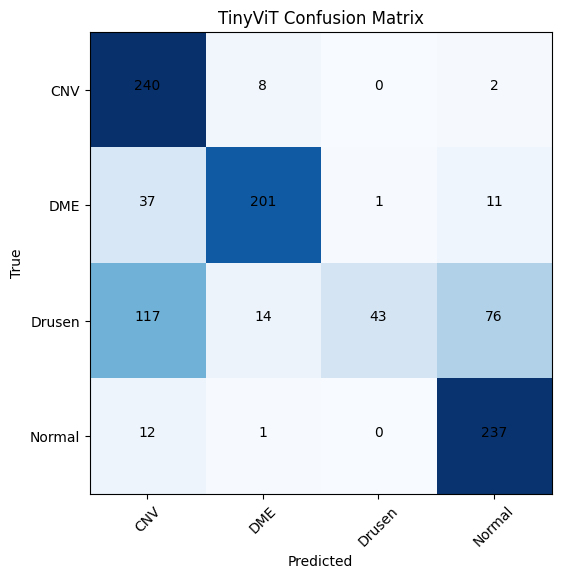

In [ ]:
cm=confusion_matrix(

    y_true_tiny,

    y_preds_tiny

)


plt.figure(

    figsize=(8,6)

)


plt.imshow(

    cm,

    cmap='Blues'

)


classes=[

    "CNV",

    "DME",

    "Drusen",

    "Normal"

]


ticks=np.arange(

    len(classes)

)


plt.xticks(

    ticks,

    classes,

    rotation=45

)


plt.yticks(

    ticks,

    classes

)


for i in range(

    cm.shape[0]

):

    for j in range(

        cm.shape[1]

    ):

        plt.text(

            j,

            i,

            cm[i,j],

            ha='center'

        )


plt.title(

    "TinyViT Confusion Matrix"

)

plt.ylabel(

    "True"

)

plt.xlabel(

    "Predicted"

)

plt.show()

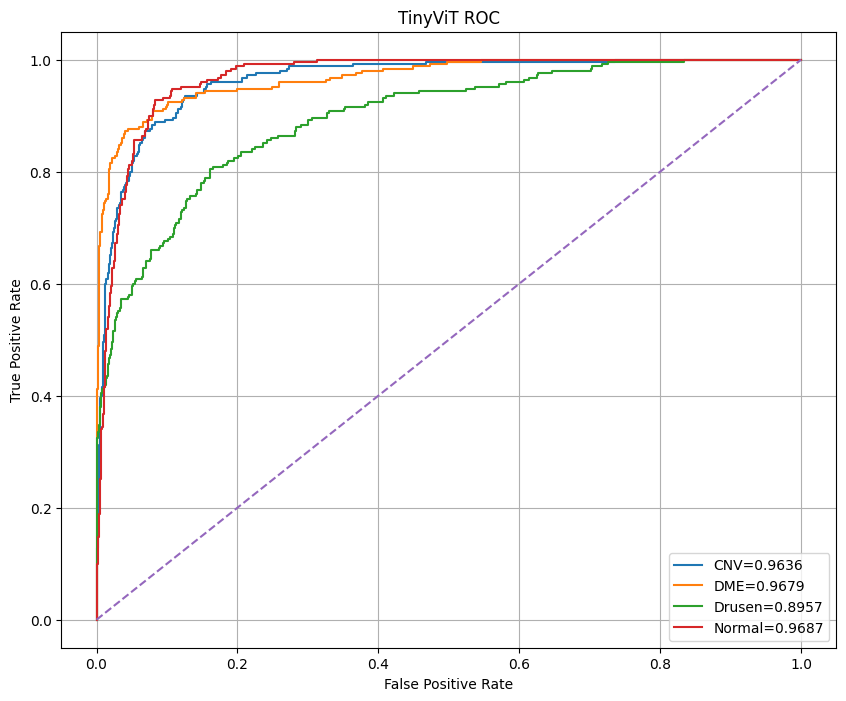

In [ ]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc


y_true_bin=label_binarize(

    y_true_tiny,

    classes=[0,1,2,3]

)


names=[

    "CNV",

    "DME",

    "Drusen",

    "Normal"

]


plt.figure(

    figsize=(10,8)

)


for i in range(4):


    fpr,tpr,_=roc_curve(

        y_true_bin[:,i],

        np.array(

            y_probs_tiny

        )[:,i]

    )


    roc_auc=auc(

        fpr,

        tpr

    )


    plt.plot(

        fpr,

        tpr,

        label=f"{names[i]}={roc_auc:.4f}"

    )


plt.plot(

    [0,1],

    [0,1],

    linestyle='--'

)


plt.xlabel(

    "False Positive Rate"

)

plt.ylabel(

    "True Positive Rate"

)

plt.title(

    "TinyViT ROC"

)

plt.legend()

plt.grid()

plt.show()

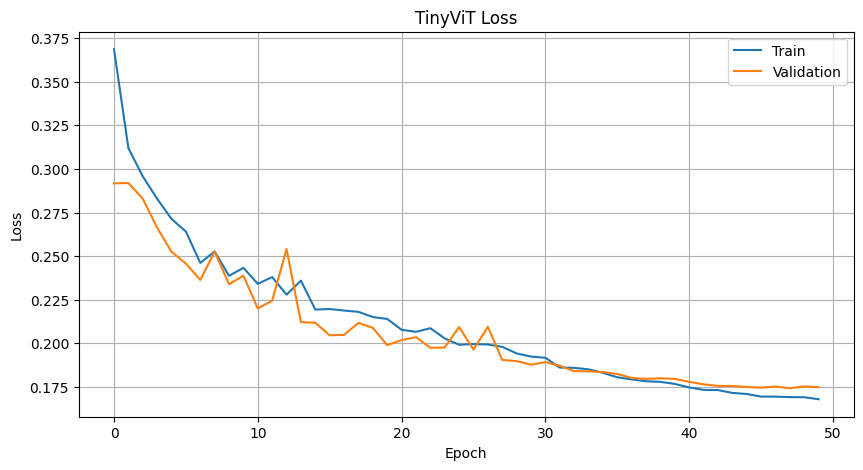

In [ ]:
plt.figure(

    figsize=(10,5)

)


plt.plot(

    history_tinyvit[

        "train_loss"

    ],

    label='Train'

)


plt.plot(

    history_tinyvit[

        "val_loss"

    ],

    label='Validation'

)


plt.xlabel(

    "Epoch"

)

plt.ylabel(

    "Loss"

)

plt.legend()

plt.grid()

plt.title(

    "TinyViT Loss"

)

plt.show()

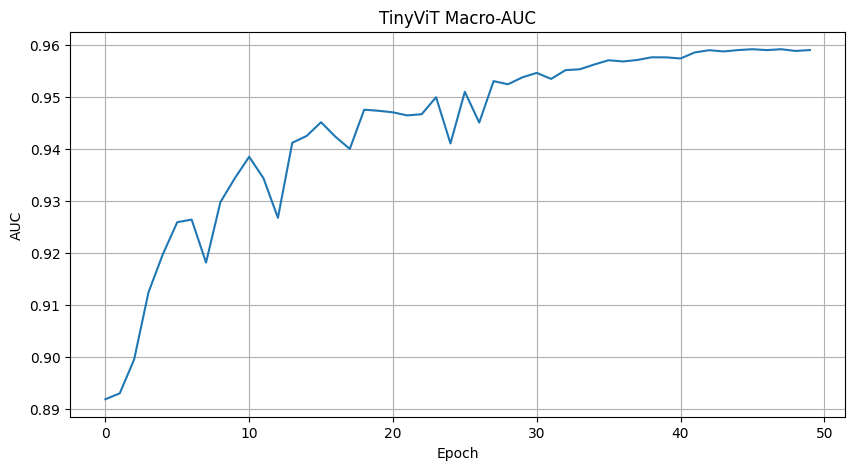

In [ ]:
plt.figure(

    figsize=(10,5)

)


plt.plot(

    history_tinyvit[

        "val_auc"

    ]

)


plt.grid()

plt.xlabel(

    "Epoch"

)

plt.ylabel(

    "AUC"

)

plt.title(

    "TinyViT Macro-AUC"

)

plt.show()

In [ ]:
report_dict=classification_report(

    y_true_tiny,

    y_preds_tiny,

    output_dict=True,

    target_names=[

        "CNV",

        "DME",

        "Drusen",

        "Normal"

    ]

)


paper_tiny=pd.DataFrame({

    "Class":[

        "CNV",

        "DME",

        "Drusen",

        "Normal"

    ],

    "Precision":[

        report_dict["CNV"]["precision"],

        report_dict["DME"]["precision"],

        report_dict["Drusen"]["precision"],

        report_dict["Normal"]["precision"]

    ],

    "Recall":[

        report_dict["CNV"]["recall"],

        report_dict["DME"]["recall"],

        report_dict["Drusen"]["recall"],

        report_dict["Normal"]["recall"]

    ],

    "F1":[

        report_dict["CNV"]["f1-score"],

        report_dict["DME"]["f1-score"],

        report_dict["Drusen"]["f1-score"],

        report_dict["Normal"]["f1-score"]

    ]

})


paper_tiny=paper_tiny.round(

    4

)


print(

    paper_tiny

)

    Class  Precision  Recall      F1
0     CNV     0.5911   0.960  0.7317
1     DME     0.8973   0.804  0.8481
2  Drusen     0.9773   0.172  0.2925
3  Normal     0.7270   0.948  0.8229


DenseNet121-LT

In [ ]:
import os
import gc
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

from tqdm import tqdm

from sklearn.metrics import(
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.preprocessing import(
    label_binarize
)

from torch.cuda.amp import(
    autocast,
    GradScaler
)

warnings.filterwarnings(

    "ignore"

)

device=torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"

)

print(device)

cuda


In [ ]:
class FocalLoss(

    nn.Module

):

    def __init__(

        self,

        alpha=.75,

        gamma=1.5

    ):

        super().__init__()


        self.alpha=alpha

        self.gamma=gamma


    def forward(

        self,

        inputs,

        targets

    ):


        ce=nn.functional.cross_entropy(

            inputs,

            targets,

            reduction='none',

            label_smoothing=.1

        )


        pt=torch.exp(

            -ce

        )


        loss=(

            self.alpha*

            ((1-pt)**self.gamma)*

            ce

        )


        return loss.mean()


criterion=FocalLoss()

In [ ]:
class FocalLoss(

    nn.Module

):

    def __init__(

        self,

        alpha=.75,

        gamma=1.5

    ):

        super().__init__()


        self.alpha=alpha

        self.gamma=gamma


    def forward(

        self,

        inputs,

        targets

    ):


        ce=nn.functional.cross_entropy(

            inputs,

            targets,

            reduction='none',

            label_smoothing=.1

        )


        pt=torch.exp(

            -ce

        )


        loss=(

            self.alpha*

            ((1-pt)**self.gamma)*

            ce

        )


        return loss.mean()


criterion=FocalLoss()

In [ ]:
model_dense=models.densenet121(

    weights=None

)


model_dense.features.conv0=nn.Conv2d(

    1,

    64,

    kernel_size=3,

    stride=1,

    padding=1,

    bias=False

)


model_dense.features.pool0=nn.Identity()


num_features=(

    model_dense.classifier.in_features

)


model_dense.classifier=nn.Sequential(

    nn.Dropout(.3),

    nn.Linear(

        num_features,

        4

    )

)


model_dense=model_dense.to(

    device

)

In [ ]:
dummy=torch.randn(

    2,

    1,

    28,

    28

).to(device)


out=model_dense(

    dummy

)


print(

    out.shape

)

torch.Size([2, 4])


In [ ]:
params=sum(

    p.numel()

    for p in model_dense.parameters()

)


print(

f"Parameters:{params:,}"

)

Parameters:6,949,124


In [ ]:
optimizer_dense=optim.AdamW(

    model_dense.parameters(),

    lr=5e-4,

    weight_decay=1e-4

)


scheduler_dense=torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer_dense,

    T_max=50,

    eta_min=1e-6

)


scaler_dense=GradScaler()

In [ ]:
best_val_loss_dense=np.inf

patience_dense=7

counter_dense=0


history_dense={

    "train_loss":[],

    "val_loss":[],

    "val_auc":[],

    "val_acc":[]

}

In [ ]:
CHECKPOINT_PATH="dense_checkpoint.pth"

BEST_MODEL_PATH="best_dense_model.pth"

In [ ]:
if os.path.exists(

    CHECKPOINT_PATH

):

    os.remove(

        CHECKPOINT_PATH

    )


if os.path.exists(

    BEST_MODEL_PATH

):

    os.remove(

        BEST_MODEL_PATH

    )


print(

"checkpoint resetado"

)

checkpoint resetado


In [ ]:
total=sum(

    p.numel()

    for p in model_dense.parameters()

)


trainable=sum(

    p.numel()

    for p in model_dense.parameters()

    if p.requires_grad

)


print(

f"Total:{total:,}"

)

print(

f"Trainable:{trainable:,}"

)

Total:6,949,124
Trainable:6,949,124


In [ ]:
import os
import gc
import time
import numpy as np

EPOCHS=50

start_epoch=0


if os.path.exists(

    CHECKPOINT_PATH

):

    print(

        "\nCheckpoint encontrado"

    )


    checkpoint=torch.load(

        CHECKPOINT_PATH,

        map_location=device,

        weights_only=False

    )


    model_dense.load_state_dict(

        checkpoint["model_state_dict"]

    )


    optimizer_dense.load_state_dict(

        checkpoint["optimizer_state_dict"]

    )


    scheduler_dense.load_state_dict(

        checkpoint["scheduler_state_dict"]

    )


    scaler_dense.load_state_dict(

        checkpoint["scaler_state_dict"]

    )


    history_dense=checkpoint["history"]


    best_val_loss_dense=checkpoint["best_val_loss"]


    counter_dense=checkpoint["counter"]


    start_epoch=checkpoint["epoch"]+1


    print(

        f"Retomando época {start_epoch}"

    )


else:


    history_dense={

        "train_loss":[],

        "val_loss":[],

        "val_auc":[],

        "val_acc":[]

    }


    best_val_loss_dense=np.inf

    counter_dense=0


    print(

        "\nTreino iniciado do zero"

    )


for epoch in range(

    start_epoch,

    EPOCHS

):


    epoch_start=time.time()


    torch.cuda.empty_cache()

    gc.collect()


    model_dense.train()

    train_loss=0


    loop=tqdm(

        train_loader,

        total=len(train_loader),

        leave=True

    )


    for images,labels in loop:


        images=images.to(device)

        labels=labels.to(device)


        optimizer_dense.zero_grad(

            set_to_none=True

        )


        with autocast():

            outputs=model_dense(

                images

            )


            loss=criterion(

                outputs,

                labels

            )


        scaler_dense.scale(

            loss

        ).backward()


        torch.nn.utils.clip_grad_norm_(

            model_dense.parameters(),

            max_norm=1.0

        )


        scaler_dense.step(

            optimizer_dense

        )


        scaler_dense.update()


        train_loss+=loss.item()


        current_lr=(

            optimizer_dense

            .param_groups[0]["lr"]

        )


        loop.set_description(

            f"Epoch [{epoch+1}/{EPOCHS}]"

        )


        loop.set_postfix({

            "loss":

            f"{loss.item():.4f}",

            "lr":

            f"{current_lr:.6f}"

        })


    train_loss/=len(

        train_loader

    )


    scheduler_dense.step()


    model_dense.eval()


    val_loss=0


    y_true=[]

    y_probs=[]

    y_preds=[]


    with torch.no_grad():

        for images,labels in val_loader:


            images=images.to(device)

            labels=labels.to(device)


            with autocast():

                outputs=model_dense(

                    images

                )


                loss=criterion(

                    outputs,

                    labels

                )


                probs=torch.softmax(

                    outputs,

                    dim=1

                )


            preds=torch.argmax(

                probs,

                dim=1

            )


            val_loss+=loss.item()


            y_true.extend(

                labels.cpu().numpy()

            )


            y_probs.extend(

                probs.cpu().numpy()

            )


            y_preds.extend(

                preds.cpu().numpy()

            )


    val_loss/=len(

        val_loader

    )


    val_auc=compute_macro_auc(

        np.array(y_true),

        np.array(y_probs)

    )


    val_acc=accuracy_score(

        y_true,

        y_preds

    )


    history_dense[

        "train_loss"

    ].append(

        train_loss

    )


    history_dense[

        "val_loss"

    ].append(

        val_loss

    )


    history_dense[

        "val_auc"

    ].append(

        val_auc

    )


    history_dense[

        "val_acc"

    ].append(

        val_acc

    )


    epoch_time=time.time()-epoch_start


    print("\n"+"="*60)

    print(

        f"Epoch {epoch+1}/{EPOCHS}"

    )

    print("="*60)

    print(

        f"Train Loss : {train_loss:.4f}"

    )

    print(

        f"Val Loss   : {val_loss:.4f}"

    )

    print(

        f"Val Acc    : {val_acc:.4f}"

    )

    print(

        f"Val AUC    : {val_auc:.4f}"

    )

    print(

        f"LR         : {current_lr:.6f}"

    )

    print(

        f"Time       : {epoch_time:.2f}s"

    )

    print("="*60)


    checkpoint={

        "epoch":epoch,

        "model_state_dict":

        model_dense.state_dict(),

        "optimizer_state_dict":

        optimizer_dense.state_dict(),

        "scheduler_state_dict":

        scheduler_dense.state_dict(),

        "scaler_state_dict":

        scaler_dense.state_dict(),

        "history":

        history_dense,

        "best_val_loss":

        best_val_loss_dense,

        "counter":

        counter_dense

    }


    torch.save(

        checkpoint,

        CHECKPOINT_PATH

    )


    print(

        "Checkpoint salvo"

    )


    if val_loss<best_val_loss_dense:


        best_val_loss_dense=val_loss


        counter_dense=0


        torch.save(

            model_dense.state_dict(),

            BEST_MODEL_PATH

        )


        print(

            "Melhor modelo salvo"

        )


    else:


        counter_dense+=1


        print(

            f"EarlyStopping Counter:{counter_dense}"

        )


    if counter_dense>=patience_dense:


        print(

            "\nEarly stopping"

        )

        break


    torch.cuda.empty_cache()

    gc.collect()


Treino iniciado do zero


Epoch [1/50]: 100%|██████████| 3047/3047 [03:58<00:00, 12.80it/s, loss=0.1588, lr=0.000500]



Epoch 1/50
Train Loss : 0.2756
Val Loss   : 0.1860
Val Acc    : 0.8827
Val AUC    : 0.9507
LR         : 0.000500
Time       : 246.46s
Checkpoint salvo
Melhor modelo salvo


Epoch [2/50]: 100%|██████████| 3047/3047 [03:57<00:00, 12.83it/s, loss=0.0645, lr=0.000500]



Epoch 2/50
Train Loss : 0.1881
Val Loss   : 0.1714
Val Acc    : 0.8914
Val AUC    : 0.9598
LR         : 0.000500
Time       : 245.58s
Checkpoint salvo
Melhor modelo salvo


...


Epoch 32/50
Train Loss : 0.0931
Val Loss   : 0.1246
Val Acc    : 0.9391
Val AUC    : 0.9822
LR         : 0.000159
Time       : 242.62s
Checkpoint salvo
EarlyStopping Counter:5


Epoch [33/50]: 100%|██████████| 3047/3047 [03:53<00:00, 13.03it/s, loss=0.4936, lr=0.000144]



Epoch 33/50
Train Loss : 0.0914
Val Loss   : 0.1281
Val Acc    : 0.9375
Val AUC    : 0.9813
LR         : 0.000144
Time       : 241.93s
Checkpoint salvo
EarlyStopping Counter:6


Epoch [34/50]: 100%|██████████| 3047/3047 [03:53<00:00, 13.03it/s, loss=0.0455, lr=0.000130]



Epoch 34/50
Train Loss : 0.0903
Val Loss   : 0.1269
Val Acc    : 0.9372
Val AUC    : 0.9813
LR         : 0.000130
Time       : 241.81s
Checkpoint salvo
EarlyStopping Counter:7

Early stopping


In [ ]:
test_acc_dense=accuracy_score(

    y_true_dense,

    y_preds_dense

)


test_auc_dense=compute_macro_auc(

    np.array(

        y_true_dense

    ),

    np.array(

        y_probs_dense

    )

)


precision_dense=precision_score(

    y_true_dense,

    y_preds_dense,

    average='macro'

)


recall_dense=recall_score(

    y_true_dense,

    y_preds_dense,

    average='macro'

)


f1_dense=f1_score(

    y_true_dense,

    y_preds_dense,

    average='macro'

)


print(

"\n========== DENSENET121 RESULTS ==========\n"

)

print(

f"Accuracy : {test_acc_dense:.4f}"

)

print(

f"Macro AUC: {test_auc_dense:.4f}"

)

print(

f"Precision: {precision_dense:.4f}"

)

print(

f"Recall   : {recall_dense:.4f}"

)

print(

f"F1 Score : {f1_dense:.4f}"

)


========== DENSENET121 RESULTS ==========

Accuracy : 0.7670
Macro AUC: 0.9527
Precision: 0.8153
Recall   : 0.7670
F1 Score : 0.7417


In [ ]:
report_dense=classification_report(

    y_true_dense,

    y_preds_dense,

    target_names=[

        "CNV",

        "DME",

        "Drusen",

        "Normal"

    ]

)

print(

    report_dense

)

              precision    recall  f1-score   support

         CNV       0.63      0.98      0.77       250
         DME       0.89      0.86      0.88       250
      Drusen       0.94      0.32      0.47       250
      Normal       0.80      0.90      0.85       250

    accuracy                           0.77      1000
   macro avg       0.82      0.77      0.74      1000
weighted avg       0.82      0.77      0.74      1000



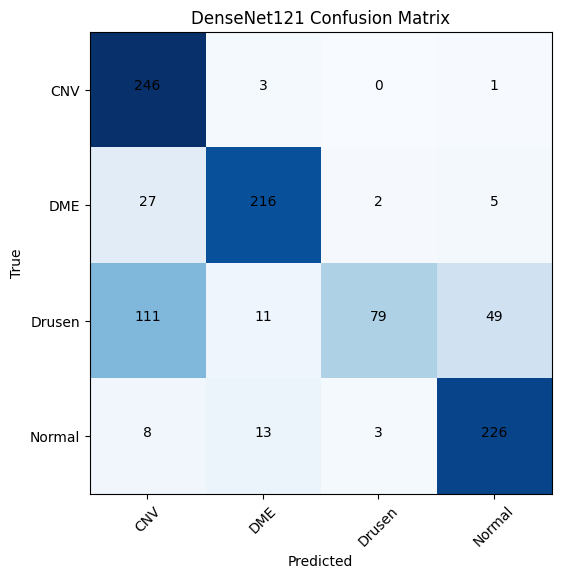

In [ ]:
cm=confusion_matrix(

    y_true_dense,

    y_preds_dense

)


plt.figure(

    figsize=(8,6)

)


plt.imshow(

    cm,

    cmap='Blues'

)


classes=[

    "CNV",

    "DME",

    "Drusen",

    "Normal"

]


ticks=np.arange(

    len(classes)

)


plt.xticks(

    ticks,

    classes,

    rotation=45

)


plt.yticks(

    ticks,

    classes

)


for i in range(

    cm.shape[0]

):

    for j in range(

        cm.shape[1]

    ):

        plt.text(

            j,

            i,

            cm[i,j],

            ha='center'

        )


plt.title(

    "DenseNet121 Confusion Matrix"

)

plt.ylabel(

    "True"

)

plt.xlabel(

    "Predicted"

)

plt.show()

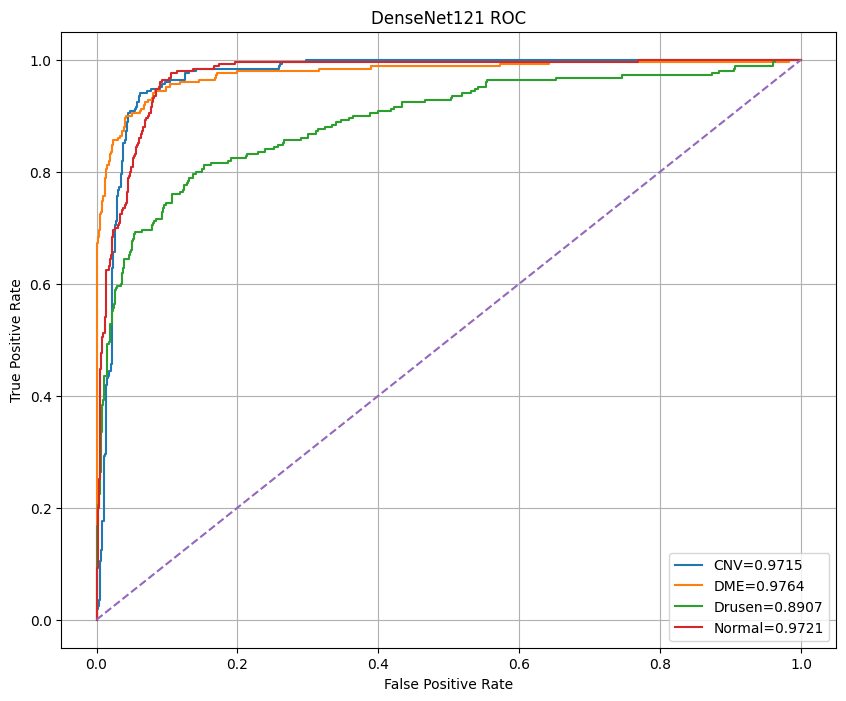

In [ ]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc


y_true_bin=label_binarize(

    y_true_dense,

    classes=[0,1,2,3]

)


names=[

    "CNV",

    "DME",

    "Drusen",

    "Normal"

]


plt.figure(

    figsize=(10,8)

)


for i in range(4):


    fpr,tpr,_=roc_curve(

        y_true_bin[:,i],

        np.array(

            y_probs_dense

        )[:,i]

    )


    roc_auc=auc(

        fpr,

        tpr

    )


    plt.plot(

        fpr,

        tpr,

        label=f"{names[i]}={roc_auc:.4f}"

    )


plt.plot(

    [0,1],

    [0,1],

    linestyle='--'

)


plt.xlabel(

    "False Positive Rate"

)

plt.ylabel(

    "True Positive Rate"

)

plt.title(

    "DenseNet121 ROC"

)

plt.legend()

plt.grid()

plt.show()

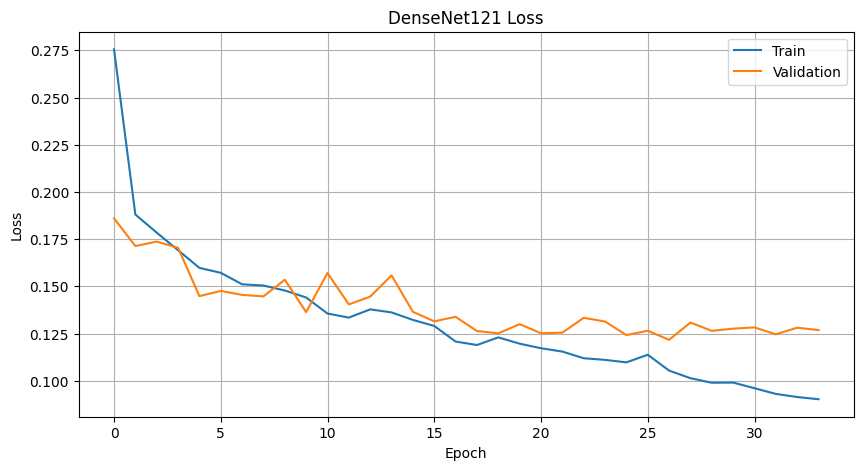

In [ ]:
plt.figure(

    figsize=(10,5)

)


plt.plot(

    history_dense[

        "train_loss"

    ],

    label='Train'

)


plt.plot(

    history_dense[

        "val_loss"

    ],

    label='Validation'

)


plt.xlabel(

    "Epoch"

)

plt.ylabel(

    "Loss"

)

plt.legend()

plt.grid()

plt.title(

    "DenseNet121 Loss"

)

plt.show()

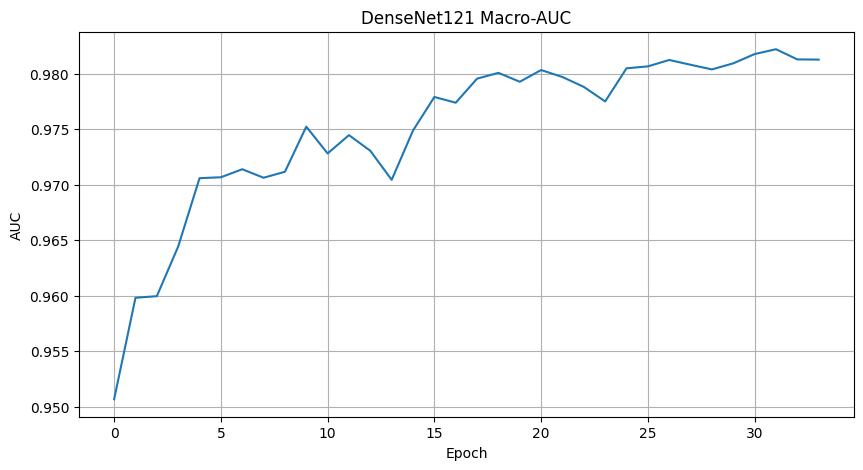

In [ ]:
plt.figure(

    figsize=(10,5)

)


plt.plot(

    history_dense[

        "val_auc"

    ]

)


plt.grid()

plt.xlabel(

    "Epoch"

)

plt.ylabel(

    "AUC"

)

plt.title(

    "DenseNet121 Macro-AUC"

)

plt.show()

In [ ]:
report_dict=classification_report(

    y_true_dense,

    y_preds_dense,

    output_dict=True,

    target_names=[

        "CNV",

        "DME",

        "Drusen",

        "Normal"

    ]

)


paper_dense=pd.DataFrame({

    "Class":[

        "CNV",

        "DME",

        "Drusen",

        "Normal"

    ],

    "Precision":[

        report_dict["CNV"]["precision"],

        report_dict["DME"]["precision"],

        report_dict["Drusen"]["precision"],

        report_dict["Normal"]["precision"]

    ],

    "Recall":[

        report_dict["CNV"]["recall"],

        report_dict["DME"]["recall"],

        report_dict["Drusen"]["recall"],

        report_dict["Normal"]["recall"]

    ],

    "F1":[

        report_dict["CNV"]["f1-score"],

        report_dict["DME"]["f1-score"],

        report_dict["Drusen"]["f1-score"],

        report_dict["Normal"]["f1-score"]

    ]

})


paper_dense=paper_dense.round(

    4

)


print(

    paper_dense

)

    Class  Precision  Recall      F1
0     CNV     0.6276   0.984  0.7664
1     DME     0.8889   0.864  0.8763
2  Drusen     0.9405   0.316  0.4731
3  Normal     0.8043   0.904  0.8512


MaxViT-LT

In [ ]:
!pip install -q timm albumentations medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 14.1 MB/s eta 0:00:00


In [ ]:
import os
import gc
import cv2
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast
from torch.cuda.amp import GradScaler

import albumentations as A

from albumentations.pytorch import ToTensorV2

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import medmnist
from medmnist import INFO
from medmnist import OCTMNIST

import timm

warnings.filterwarnings("ignore")

In [ ]:
SEED = 42

def seed_everything(seed=42):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    torch.cuda.manual_seed(seed)

    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = True


seed_everything(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [ ]:
train_transform = A.Compose([

    A.Resize(224, 224),

    A.HorizontalFlip(p=0.5),

    A.VerticalFlip(p=0.5),

    A.RandomBrightnessContrast(
        p=0.2
    ),

    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.05,
        rotate_limit=10,
        p=0.1
    ),

    A.Normalize(
        mean=(0.5,),
        std=(0.5,)
    ),

    ToTensorV2()

])


val_transform = A.Compose([

    A.Resize(224, 224),

    A.Normalize(
        mean=(0.5,),
        std=(0.5,)
    ),

    ToTensorV2()

])

In [ ]:
class OCTDataset(Dataset):

    def __init__(
        self,
        split="train",
        transform=None
    ):

        self.data = OCTMNIST(
            split=split,
            download=True
        )

        self.transform = transform


    def __len__(self):

        return len(self.data)


    def __getitem__(self, idx):

        image, label = self.data[idx]

        image = np.array(image)

        if len(image.shape) == 2:

            image = cv2.cvtColor(
                image,
                cv2.COLOR_GRAY2RGB
            )

        if self.transform:

            augmented = self.transform(
                image=image
            )

            image = augmented["image"]

        label = torch.tensor(
            label,
            dtype=torch.long
        ).squeeze()

        return image, label

In [ ]:
BATCH_SIZE = 32


train_dataset = OCTDataset(
    split="train",
    transform=train_transform
)

val_dataset = OCTDataset(
    split="val",
    transform=val_transform
)

test_dataset = OCTDataset(
    split="test",
    transform=val_transform
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

100%|██████████| 54.9M/54.9M [00:03<00:00, 13.8MB/s]


97477
10832
1000


In [ ]:
class FocalLoss(nn.Module):

    def __init__(
        self,
        gamma=2,
        alpha=1
    ):

        super().__init__()

        self.gamma = gamma

        self.alpha = alpha


    def forward(
        self,
        inputs,
        targets
    ):

        ce_loss = nn.CrossEntropyLoss(
            reduction="none"
        )(inputs, targets)

        pt = torch.exp(-ce_loss)

        focal_loss = (
            self.alpha *
            ((1 - pt) ** self.gamma) *
            ce_loss
        )

        return focal_loss.mean()

In [ ]:
class MaxViTLT(nn.Module):

    def __init__(self):

        super().__init__()

        self.backbone = timm.create_model(

            "maxvit_tiny_tf_224",

            pretrained=True,

            num_classes=0,

            global_pool="avg"
        )

        in_features = self.backbone.num_features

        self.dropout = nn.Dropout(0.3)

        self.classifier = nn.Linear(
            in_features,
            4
        )


    def forward(self, x):

        x = self.backbone(x)

        x = self.dropout(x)

        x = self.classifier(x)

        return x

In [ ]:
model_maxvit = MaxViTLT().to(device)

dummy = torch.randn(
    2,
    3,
    224,
    224
).to(device)

out = model_maxvit(dummy)

print(out.shape)

model.safetensors:   0%|          | 0.00/124M [00:00<?, ?B/s]

torch.Size([2, 4])


In [ ]:
criterion = FocalLoss(
    gamma=2
)

optimizer_maxvit = optim.AdamW(

    model_maxvit.parameters(),

    lr=7e-4,

    weight_decay=1e-4
)

scheduler_maxvit = optim.lr_scheduler.CosineAnnealingLR(

    optimizer_maxvit,

    T_max=50
)

scaler_maxvit = GradScaler()

In [ ]:
history_maxvit = {

    "train_loss": [],

    "val_loss": [],

    "val_acc": [],

    "val_auc": []
}


best_val_loss_maxvit = np.inf

patience_maxvit = 7

counter_maxvit = 0


CHECKPOINT_PATH = "maxvit_checkpoint.pth"

BEST_MODEL_PATH = "best_maxvit_model.pth"

In [ ]:
def compute_macro_auc(
    y_true,
    y_probs
):

    y_true_onehot = np.eye(4)[y_true]

    auc = roc_auc_score(

        y_true_onehot,

        y_probs,

        multi_class="ovr",

        average="macro"
    )

    return auc

In [ ]:
import os
import gc
import time
import numpy as np

EPOCHS = 50

start_epoch = 0


if os.path.exists(CHECKPOINT_PATH):

    print("\nCheckpoint encontrado")

    checkpoint = torch.load(

        CHECKPOINT_PATH,

        map_location=device,

        weights_only=False

    )


    model_maxvit.load_state_dict(

        checkpoint["model_state_dict"]

    )


    optimizer_maxvit.load_state_dict(

        checkpoint["optimizer_state_dict"]

    )


    scheduler_maxvit.load_state_dict(

        checkpoint["scheduler_state_dict"]

    )


    scaler_maxvit.load_state_dict(

        checkpoint["scaler_state_dict"]

    )


    history_maxvit = checkpoint["history"]


    best_val_loss_maxvit = checkpoint["best_val_loss"]


    counter_maxvit = checkpoint["counter"]


    start_epoch = checkpoint["epoch"] + 1


    print(

        f"Continuando da época {start_epoch}"

    )

else:

    print(

        "\nTreino iniciado do zero"

    )


for epoch in range(

    start_epoch,

    EPOCHS

):

    epoch_start = time.time()

    torch.cuda.empty_cache()

    gc.collect()


    model_maxvit.train()

    train_loss = 0.0


    loop = tqdm(

        train_loader,

        total=len(train_loader),

        leave=True

    )


    for images, labels in loop:


        images = images.to(device)

        labels = labels.to(device)


        optimizer_maxvit.zero_grad(

            set_to_none=True

        )


        with autocast():

            outputs = model_maxvit(

                images

            )


            loss = criterion(

                outputs,

                labels

            )


        scaler_maxvit.scale(

            loss

        ).backward()


        scaler_maxvit.step(

            optimizer_maxvit

        )


        scaler_maxvit.update()


        train_loss += loss.item()


        current_lr = optimizer_maxvit.param_groups[0]["lr"]


        loop.set_description(

            f"Epoch [{epoch+1}/{EPOCHS}]"

        )


        loop.set_postfix({

            "loss":
            f"{loss.item():.4f}",

            "lr":
            f"{current_lr:.6f}"

        })


    train_loss /= len(

        train_loader

    )


    scheduler_maxvit.step()


    model_maxvit.eval()


    val_loss = 0


    y_true = []

    y_probs = []

    y_preds = []


    with torch.no_grad():

        for images, labels in val_loader:


            images = images.to(device)

            labels = labels.to(device)


            with autocast():

                outputs = model_maxvit(

                    images

                )


                loss = criterion(

                    outputs,

                    labels

                )


                probs = torch.softmax(

                    outputs,

                    dim=1

                )


            preds = torch.argmax(

                probs,

                dim=1

            )


            val_loss += loss.item()


            y_true.extend(

                labels.cpu().numpy()

            )


            y_probs.extend(

                probs.cpu().numpy()

            )


            y_preds.extend(

                preds.cpu().numpy()

            )


    val_loss /= len(

        val_loader

    )


    val_auc = compute_macro_auc(

        np.array(y_true),

        np.array(y_probs)

    )


    val_acc = accuracy_score(

        y_true,

        y_preds

    )


    history_maxvit[

        "train_loss"

    ].append(

        train_loss

    )


    history_maxvit[

        "val_loss"

    ].append(

        val_loss

    )


    history_maxvit[

        "val_auc"

    ].append(

        val_auc

    )


    history_maxvit[

        "val_acc"

    ].append(

        val_acc

    )


    epoch_time = (

        time.time()

        -

        epoch_start

    )


    print("\n" + "="*60)

    print(

        f"Epoch {epoch+1}/{EPOCHS}"

    )

    print("="*60)

    print(

        f"Train Loss : {train_loss:.4f}"

    )

    print(

        f"Val Loss   : {val_loss:.4f}"

    )

    print(

        f"Val Acc    : {val_acc:.4f}"

    )

    print(

        f"Val AUC    : {val_auc:.4f}"

    )

    print(

        f"LR         : {current_lr:.6f}"

    )

    print(

        f"Time       : {epoch_time:.2f}s"

    )

    print("="*60)


    checkpoint = {

        "epoch": epoch,

        "model_state_dict":
        model_maxvit.state_dict(),

        "optimizer_state_dict":
        optimizer_maxvit.state_dict(),

        "scheduler_state_dict":
        scheduler_maxvit.state_dict(),

        "scaler_state_dict":
        scaler_maxvit.state_dict(),

        "history":
        history_maxvit,

        "best_val_loss":
        best_val_loss_maxvit,

        "counter":
        counter_maxvit

    }


    torch.save(

        checkpoint,

        CHECKPOINT_PATH

    )


    print(

        "Checkpoint salvo"

    )


    if val_loss < best_val_loss_maxvit:


        best_val_loss_maxvit = val_loss


        counter_maxvit = 0


        torch.save(

            model_maxvit.state_dict(),

            BEST_MODEL_PATH

        )


        print(

            "Melhor modelo salvo"

        )


    else:


        counter_maxvit += 1


        print(

            f"EarlyStopping Counter: {counter_maxvit}"

        )


    if counter_maxvit >= patience_maxvit:


        print(

            "\nEarly stopping"

        )


        break


    torch.cuda.empty_cache()

    gc.collect()


Treino iniciado do zero


Epoch [1/50]: 100%|██████████| 3047/3047 [13:16<00:00,  3.82it/s, loss=0.2149, lr=0.000700]



Epoch 1/50
Train Loss : 0.1694
Val Loss   : 0.1438
Val Acc    : 0.8848
Val AUC    : 0.9517
LR         : 0.000700
Time       : 823.04s
Checkpoint salvo
Melhor modelo salvo


Epoch [2/50]: 100%|██████████| 3047/3047 [10:42<00:00,  4.74it/s, loss=0.0329, lr=0.000699]



Epoch 2/50
Train Loss : 0.1296
Val Loss   : 0.1276
Val Acc    : 0.8882
Val AUC    : 0.9613
LR         : 0.000699
Time       : 664.79s
Checkpoint salvo
Melhor modelo salvo


...


Epoch 23/50
Train Loss : 0.0194
Val Loss   : 0.0797
Val Acc    : 0.9427
Val AUC    : 0.9858
LR         : 0.000416
Time       : 660.29s
Checkpoint salvo
EarlyStopping Counter: 5


Epoch [24/50]: 100%|██████████| 3047/3047 [10:38<00:00,  4.77it/s, loss=0.0007, lr=0.000394]



Epoch 24/50
Train Loss : 0.0180
Val Loss   : 0.0781
Val Acc    : 0.9486
Val AUC    : 0.9869
LR         : 0.000394
Time       : 660.00s
Checkpoint salvo
EarlyStopping Counter: 6


Epoch [25/50]: 100%|██████████| 3047/3047 [10:38<00:00,  4.78it/s, loss=0.0193, lr=0.000372]



Epoch 25/50
Train Loss : 0.0151
Val Loss   : 0.0833
Val Acc    : 0.9475
Val AUC    : 0.9859
LR         : 0.000372
Time       : 659.77s
Checkpoint salvo
EarlyStopping Counter: 7

Early stopping


In [ ]:
model_maxvit.load_state_dict(

    torch.load(

        BEST_MODEL_PATH,

        map_location=device

    )

)

model_maxvit.eval()


y_true = []

y_probs = []

y_preds = []


with torch.no_grad():

    for images, labels in tqdm(test_loader):

        images = images.to(device)

        labels = labels.to(device)


        with autocast():

            outputs = model_maxvit(images)

            probs = torch.softmax(

                outputs,

                dim=1

            )


        preds = torch.argmax(

            probs,

            dim=1

        )


        y_true.extend(

            labels.cpu().numpy()

        )


        y_probs.extend(

            probs.cpu().numpy()

        )


        y_preds.extend(

            preds.cpu().numpy()

        )


y_true = np.array(y_true)

y_probs = np.array(y_probs)

y_preds = np.array(y_preds)

100%|██████████| 32/32 [00:06<00:00,  5.00it/s]


In [ ]:
accuracy = accuracy_score(

    y_true,

    y_preds

)

precision = precision_score(

    y_true,

    y_preds,

    average="macro"

)

recall = recall_score(

    y_true,

    y_preds,

    average="macro"

)

f1 = f1_score(

    y_true,

    y_preds,

    average="macro"

)


macro_auc = compute_macro_auc(

    y_true,

    y_probs

)


print("\n========== MAXVIT-LT RESULTS ==========\n")

print(f"Accuracy : {accuracy:.4f}")

print(f"Macro AUC: {macro_auc:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")


========== MAXVIT-LT RESULTS ==========

Accuracy : 0.7840
Macro AUC: 0.9691
Precision: 0.8289
Recall   : 0.7840
F1 Score : 0.7530


In [ ]:
print(np.unique(y_true))

print(np.bincount(y_true))

[0 1 2 3]
[250 250 250 250]


In [ ]:
print(np.unique(y_preds))

print(np.bincount(y_preds))

[0 1 2 3]
[368 266  77 289]


In [ ]:
cm = confusion_matrix(

    y_true,

    y_preds

)

print(cm)

[[245   5   0   0]
 [ 12 235   0   3]
 [105  13  75  57]
 [  6  13   2 229]]


In [ ]:
class_names = [

    "CNV",

    "DME",

    "Drusen",

    "Normal"

]


report = classification_report(

    y_true,

    y_preds,

    target_names=class_names,

    digits=4,

    output_dict=True

)


report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
CNV,0.665761,0.980,0.792880,250.000
DME,0.883459,0.940,0.910853,250.000
Drusen,0.974026,0.300,0.458716,250.000
Normal,0.792388,0.916,0.849722,250.000
accuracy,0.784000,0.784,0.784000,0.784
macro avg,0.828908,0.784,0.753043,1000.000
weighted avg,0.828908,0.784,0.753043,1000.000


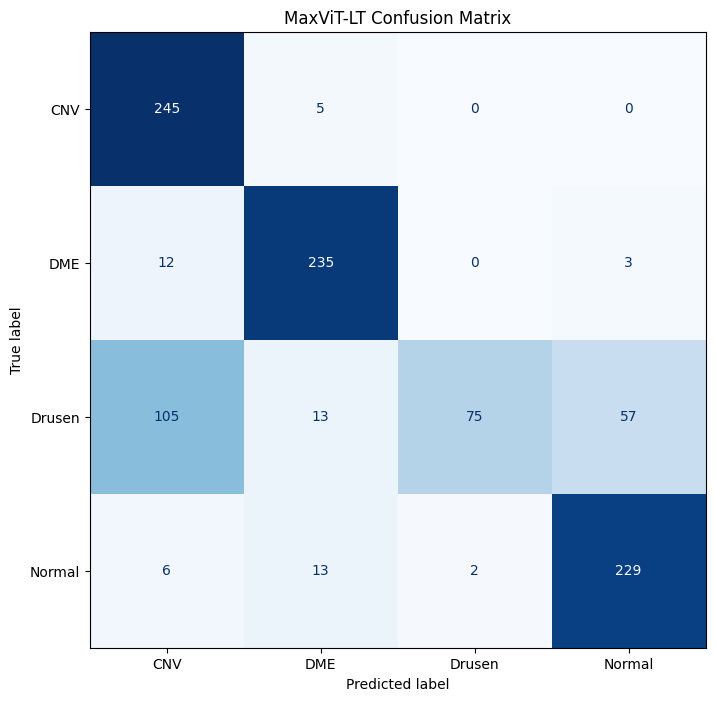

In [ ]:
cm = confusion_matrix(

    y_true,

    y_preds

)


fig, ax = plt.subplots(

    figsize=(8,8)

)


disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=class_names

)


disp.plot(

    cmap="Blues",

    ax=ax,

    colorbar=False

)

plt.title(

    "MaxViT-LT Confusion Matrix"

)

plt.show()

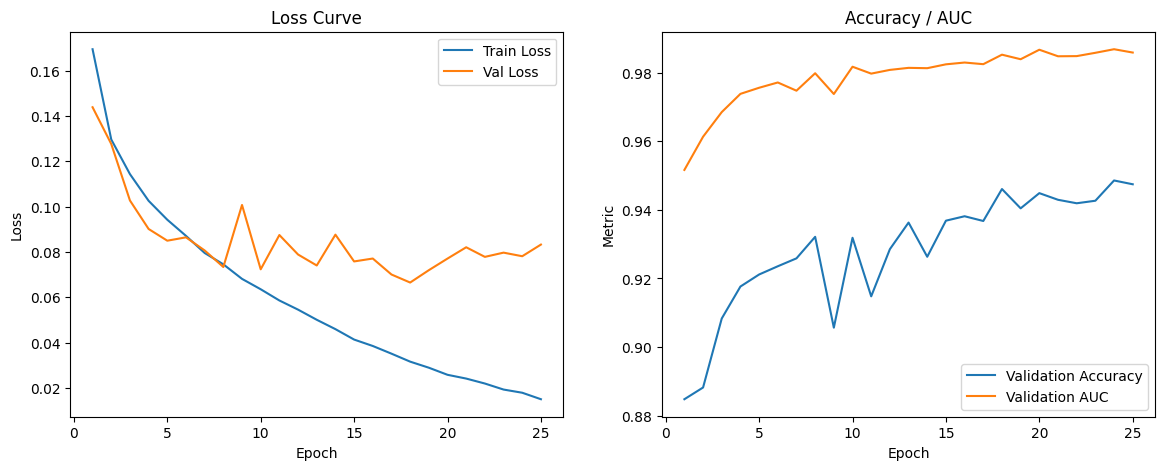

In [ ]:
epochs_range = range(

    1,

    len(history_maxvit["train_loss"]) + 1

)


plt.figure(figsize=(14,5))


plt.subplot(1,2,1)

plt.plot(

    epochs_range,

    history_maxvit["train_loss"],

    label="Train Loss"

)

plt.plot(

    epochs_range,

    history_maxvit["val_loss"],

    label="Val Loss"

)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss Curve")

plt.legend()


plt.subplot(1,2,2)

plt.plot(

    epochs_range,

    history_maxvit["val_acc"],

    label="Validation Accuracy"

)

plt.plot(

    epochs_range,

    history_maxvit["val_auc"],

    label="Validation AUC"

)

plt.xlabel("Epoch")

plt.ylabel("Metric")

plt.title("Accuracy / AUC")

plt.legend()

plt.show()

Swin Transformers

In [1]:
pip install torch torchvision timm medmnist scikit-learn tqdm matplotlib pandas seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 14.3 MB/s eta 0:00:00


In [3]:
import os
import gc
import time
import numpy as np
import torch
import torch.nn as nn

from tqdm import tqdm

from torchvision import transforms

from torch.utils.data import DataLoader

from torch.cuda.amp import GradScaler

from torch.amp import autocast

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from medmnist import OCTMNIST

import timm

In [4]:
device = torch.device(

    "cuda" if torch.cuda.is_available()

    else "cpu"

)

print(device)

cuda


In [5]:
BATCH_SIZE = 64

IMAGE_SIZE = 224

EPOCHS = 50

LR = 3e-4

NUM_CLASSES = 4

In [6]:
train_transform = transforms.Compose([

    transforms.Resize(

        (IMAGE_SIZE, IMAGE_SIZE)

    ),

    transforms.Lambda(

        lambda x: x.convert("RGB")

    ),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.5,0.5,0.5],

        std=[0.5,0.5,0.5]

    )

])

test_transform = transforms.Compose([

    transforms.Resize(

        (IMAGE_SIZE, IMAGE_SIZE)

    ),

    transforms.Lambda(

        lambda x: x.convert("RGB")

    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.5,0.5,0.5],

        std=[0.5,0.5,0.5]

    )

])

In [7]:
train_dataset = OCTMNIST(

    split="train",

    transform=train_transform,

    download=True

)

val_dataset = OCTMNIST(

    split="val",

    transform=test_transform,

    download=True

)

test_dataset = OCTMNIST(

    split="test",

    transform=test_transform,

    download=True

)

100%|██████████| 54.9M/54.9M [00:03<00:00, 13.9MB/s]


In [8]:
train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=2,

    pin_memory=True

)

val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2,

    pin_memory=True

)

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2,

    pin_memory=True

)

In [9]:
images, labels = next(

    iter(train_loader)

)

print(images.shape)

print(labels.shape)

torch.Size([64, 3, 224, 224])
torch.Size([64, 1])


In [10]:
model_swin = timm.create_model(

    "swin_tiny_patch4_window7_224",

    pretrained=True,

    num_classes=NUM_CLASSES

)

model_swin = model_swin.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

In [11]:
criterion = nn.CrossEntropyLoss()

optimizer_swin = torch.optim.AdamW(

    model_swin.parameters(),

    lr=LR,

    weight_decay=1e-4

)

scheduler_swin = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer_swin,

    T_max=EPOCHS

)

scaler_swin = GradScaler()

/tmp/ipykernel_51360/705807742.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_swin = GradScaler()


In [12]:
CHECKPOINT_PATH = "swin_checkpoint.pth"

BEST_MODEL_PATH = "best_swin_model.pth"

best_val_loss_swin = np.inf

counter_swin = 0

patience_swin = 7

start_epoch = 0

history_swin = {

    "train_loss":[],

    "val_loss":[],

    "val_auc":[],

    "val_acc":[]

}

In [13]:
def compute_macro_auc(

    y_true,

    y_probs

):

    return roc_auc_score(

        y_true,

        y_probs,

        multi_class="ovr",

        average="macro"

    )

In [ ]:
for epoch in range(

    start_epoch,

    EPOCHS

):

    epoch_start = time.time()

    torch.cuda.empty_cache()

    gc.collect()

    model_swin.train()

    train_loss = 0.0

    loop = tqdm(

        train_loader,

        total=len(train_loader),

        leave=True

    )

    for images, labels in loop:

        images = images.to(device)

        labels = labels.squeeze().long().to(device)

        optimizer_swin.zero_grad(

            set_to_none=True

        )

        with autocast(

            device_type="cuda"

        ):

            outputs = model_swin(

                images

            )

            loss = criterion(

                outputs,

                labels

            )

        scaler_swin.scale(

            loss

        ).backward()

        scaler_swin.step(

            optimizer_swin

        )

        scaler_swin.update()

        train_loss += loss.item()

        current_lr = optimizer_swin.param_groups[0]["lr"]

        loop.set_description(

            f"Epoch [{epoch+1}/{EPOCHS}]"

        )

        loop.set_postfix({

            "loss":

            f"{loss.item():.4f}",

            "lr":

            f"{current_lr:.6f}"

        })

    train_loss /= len(

        train_loader

    )

    scheduler_swin.step()

    model_swin.eval()

    val_loss = 0

    y_true = []

    y_probs = []

    y_preds = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.squeeze().long().to(device)

            with autocast(

                device_type="cuda"

            ):

                outputs = model_swin(

                    images

                )

                loss = criterion(

                    outputs,

                    labels

                )

                probs = torch.softmax(

                    outputs,

                    dim=1

                )

            preds = torch.argmax(

                probs,

                dim=1

            )

            val_loss += loss.item()

            y_true.extend(

                labels.cpu().numpy()

            )

            y_probs.extend(

                probs.cpu().numpy()

            )

            y_preds.extend(

                preds.cpu().numpy()

            )

    val_loss /= len(

        val_loader

    )

    val_auc = compute_macro_auc(

        np.array(y_true),

        np.array(y_probs)

    )

    val_acc = accuracy_score(

        y_true,

        y_preds

    )

    history_swin["train_loss"].append(

        train_loss

    )

    history_swin["val_loss"].append(

        val_loss

    )

    history_swin["val_auc"].append(

        val_auc

    )

    history_swin["val_acc"].append(

        val_acc

    )

    epoch_time = (

        time.time()

        -

        epoch_start

    )

    print("\n"+"="*60)

    print(

        f"Epoch {epoch+1}/{EPOCHS}"

    )

    print("="*60)

    print(

        f"Train Loss : {train_loss:.4f}"

    )

    print(

        f"Val Loss   : {val_loss:.4f}"

    )

    print(

        f"Val Acc    : {val_acc:.4f}"

    )

    print(

        f"Val AUC    : {val_auc:.4f}"

    )

    print(

        f"LR         : {current_lr:.6f}"

    )

    print(

        f"Time       : {epoch_time:.2f}s"

    )

    print("="*60)

    checkpoint = {

        "epoch": epoch,

        "model_state_dict":

        model_swin.state_dict(),

        "optimizer_state_dict":

        optimizer_swin.state_dict(),

        "scheduler_state_dict":

        scheduler_swin.state_dict(),

        "scaler_state_dict":

        scaler_swin.state_dict(),

        "history":

        history_swin,

        "best_val_loss":

        best_val_loss_swin,

        "counter":

        counter_swin

    }

    torch.save(

        checkpoint,

        CHECKPOINT_PATH

    )

    if val_loss < best_val_loss_swin:

        best_val_loss_swin = val_loss

        counter_swin = 0

        torch.save(

            model_swin.state_dict(),

            BEST_MODEL_PATH

        )

        print(

            "Melhor modelo salvo"

        )

    else:

        counter_swin += 1

        print(

            f"EarlyStopping Counter: {counter_swin}"

        )

    if counter_swin >= patience_swin:

        print(

            "\nEarly stopping"

        )

        break

Epoch [1/50]: 100%|██████████| 1524/1524 [05:56<00:00,  4.28it/s, loss=0.0643, lr=0.000300]



Epoch 1/50
Train Loss : 0.4741
Val Loss   : 0.3343
Val Acc    : 0.8911
Val AUC    : 0.9582
LR         : 0.000300
Time       : 370.75s
Melhor modelo salvo


Epoch [2/50]: 100%|██████████| 1524/1524 [05:55<00:00,  4.29it/s, loss=0.7995, lr=0.000300]



Epoch 2/50
Train Loss : 0.3197
Val Loss   : 0.2852
Val Acc    : 0.9040
Val AUC    : 0.9679
LR         : 0.000300
Time       : 369.93s
Melhor modelo salvo


Epoch [3/50]:  26%|██▌       | 399/1524 [01:33<04:22,  4.28it/s, loss=0.1791, lr=0.000299]

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

import torch
from tqdm import tqdm

model_swin.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

model_swin.eval()

y_true = []
y_probs = []

with torch.no_grad():

    for images, labels in tqdm(test_loader):

        images = images.repeat(1, 3, 1, 1).to(device)

        labels = labels.squeeze().long()

        outputs = model_swin(images)

        probs = torch.softmax(
            outputs,
            dim=1
        )

        y_true.extend(
            labels.numpy()
        )

        y_probs.extend(
            probs.cpu().numpy()
        )

y_true = np.array(y_true)

y_probs = np.array(y_probs)

classes = [
    "CNV",
    "DME",
    "Drusen",
    "Normal"
]

y_true_bin = label_binarize(
    y_true,
    classes=[0,1,2,3]
)

plt.figure(figsize=(10,8))

for i, class_name in enumerate(classes):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_probs[:, i]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{class_name} AUC = {roc_auc:.4f}"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlim([0.0,1.0])

plt.ylim([0.0,1.05])

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title(
    "Swin Transformer ROC Curves"
)

plt.legend(
    loc="lower right"
)

plt.grid(True)

plt.show()

NameError: name 'model_swin' is not defined


========== FINAL RESULTS ==========

Accuracy : 0.7800
Macro AUC: 0.9649
Precision: 0.8381
Recall   : 0.7800
F1 Score : 0.7555

========== CLASSIFICATION REPORT ==========

              precision    recall  f1-score   support

         CNV     0.6390    0.9840    0.7748       250
         DME     0.9464    0.8480    0.8945       250
      Drusen     0.9880    0.3280    0.4925       250
      Normal     0.7792    0.9600    0.8602       250

    accuracy                         0.7800      1000
   macro avg     0.8381    0.7800    0.7555      1000
weighted avg     0.8381    0.7800    0.7555      1000


========== CONFUSION MATRIX ==========

[[246   4   0   0]
 [ 33 212   0   5]
 [ 99   6  82  63]
 [  7   2   1 240]]


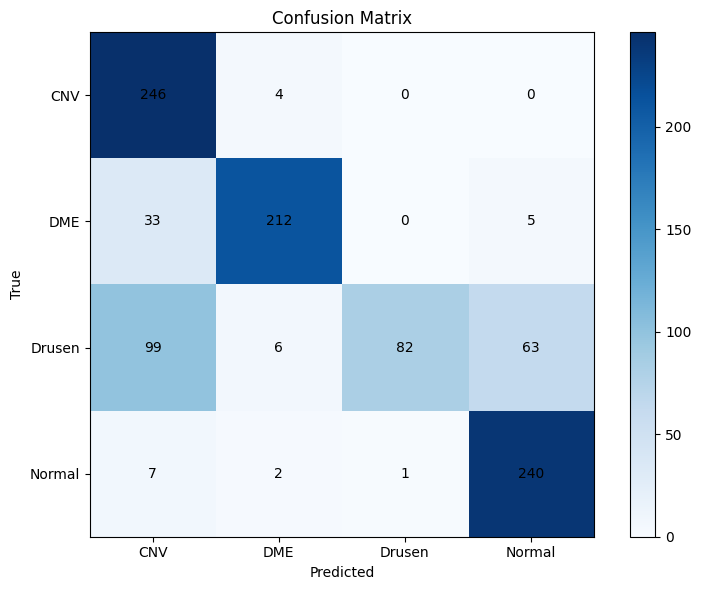

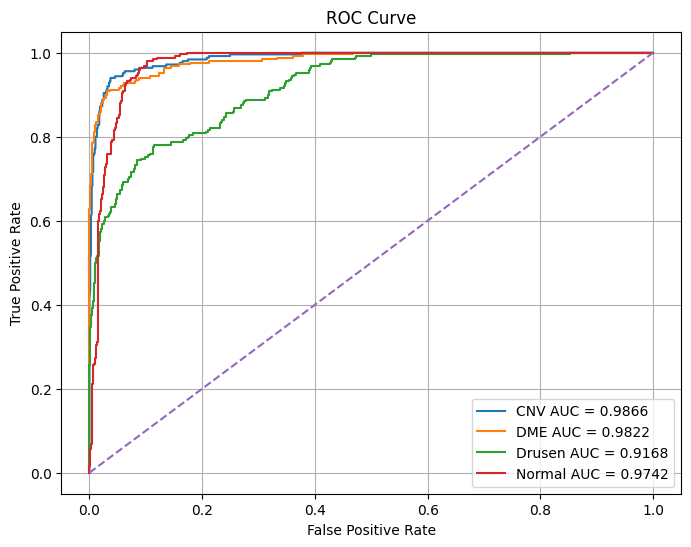

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    auc
)

model_swin.eval()

y_true = []
y_pred = []
y_probs = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        labels = labels.squeeze().long().to(device)

        if images.shape[1] == 1:
            images = images.repeat(1, 3, 1, 1)

        outputs = model_swin(images)

        probs = torch.softmax(outputs, dim=1)

        preds = torch.argmax(probs, dim=1)

        y_true.extend(labels.cpu().numpy())

        y_pred.extend(preds.cpu().numpy())

        y_probs.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="macro"
)

recall = recall_score(
    y_true,
    y_pred,
    average="macro"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

macro_auc = roc_auc_score(
    y_true,
    y_probs,
    multi_class="ovr",
    average="macro"
)

print("\n========== FINAL RESULTS ==========\n")

print(f"Accuracy : {accuracy:.4f}")
print(f"Macro AUC: {macro_auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

class_names = [
    "CNV",
    "DME",
    "Drusen",
    "Normal"
]

print("\n========== CLASSIFICATION REPORT ==========\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

cm = confusion_matrix(
    y_true,
    y_pred
)

print("\n========== CONFUSION MATRIX ==========\n")

print(cm)

plt.figure(figsize=(8,6))

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks(
    np.arange(len(class_names)),
    class_names
)

plt.yticks(
    np.arange(len(class_names)),
    class_names
)

plt.xlabel("Predicted")

plt.ylabel("True")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="black"
        )

plt.tight_layout()

plt.show()

plt.figure(figsize=(8,6))

for i in range(len(class_names)):

    fpr, tpr, _ = roc_curve(
        (y_true == i).astype(int),
        y_probs[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_names[i]} AUC = {roc_auc:.4f}"
    )

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid()

plt.show()

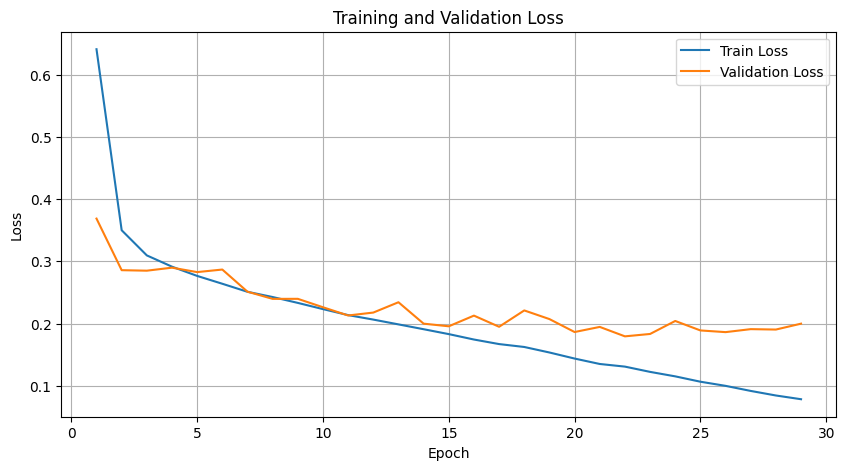

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history_swin["train_loss"]) + 1)

plt.figure(figsize=(10,5))

plt.plot(
    epochs,
    history_swin["train_loss"],
    label="Train Loss"
)

plt.plot(
    epochs,
    history_swin["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training and Validation Loss")

plt.legend()

plt.grid()

plt.show()

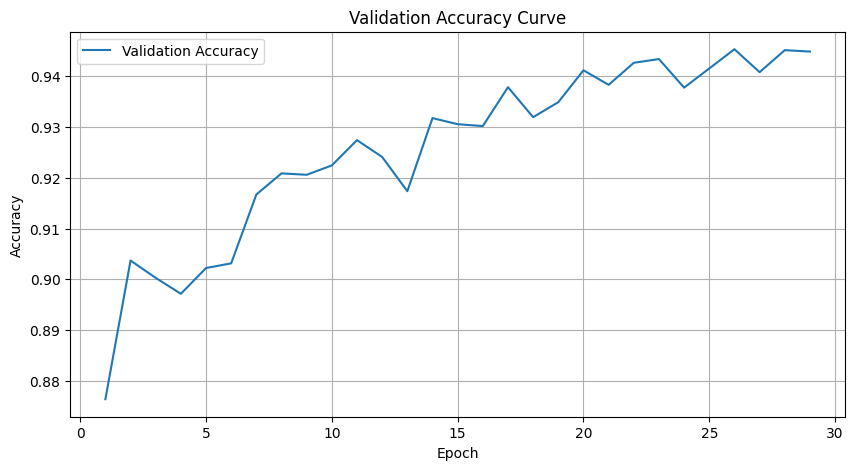

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history_swin["val_acc"]) + 1)

plt.figure(figsize=(10,5))

plt.plot(
    epochs,
    history_swin["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Validation Accuracy Curve")

plt.legend()

plt.grid()

plt.show()

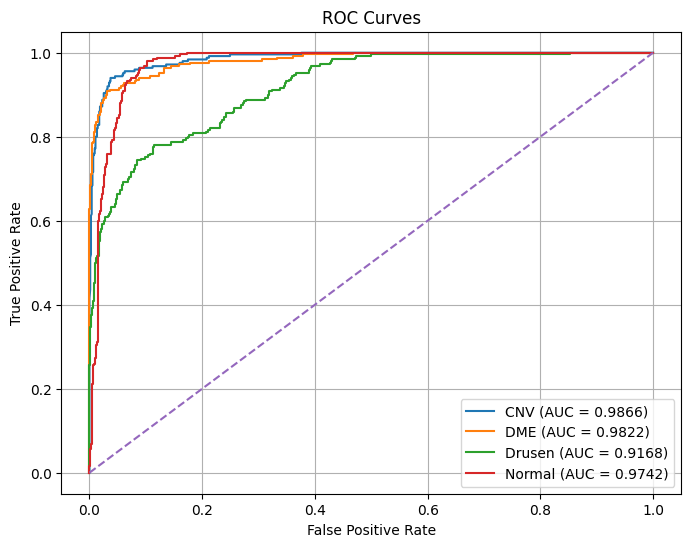

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc

class_names = [
    "CNV",
    "DME",
    "Drusen",
    "Normal"
]

plt.figure(figsize=(8,6))

for i in range(len(class_names)):

    fpr, tpr, _ = roc_curve(
        (y_true == i).astype(int),
        y_probs[:, i]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{class_names[i]} (AUC = {roc_auc:.4f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curves")

plt.legend()

plt.grid()

plt.show()

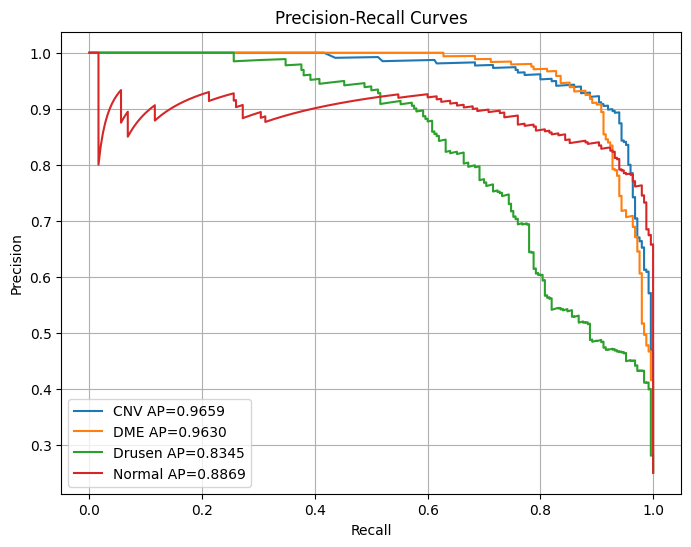

In [ ]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

plt.figure(figsize=(8,6))

for i in range(len(class_names)):

    precision_curve, recall_curve, _ = precision_recall_curve(
        (y_true == i).astype(int),
        y_probs[:, i]
    )

    ap_score = average_precision_score(
        (y_true == i).astype(int),
        y_probs[:, i]
    )

    plt.plot(
        recall_curve,
        precision_curve,
        label=f"{class_names[i]} AP={ap_score:.4f}"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid()
plt.show()

In [ ]:
import time

model_swin.eval()

starter = torch.cuda.Event(enable_timing=True)
ender = torch.cuda.Event(enable_timing=True)

times = []

with torch.no_grad():

    for images, _ in test_loader:

        images = images.to(device)

        if images.shape[1] == 1:
            images = images.repeat(1,3,1,1)

        starter.record()

        _ = model_swin(images)

        ender.record()

        torch.cuda.synchronize()

        curr_time = starter.elapsed_time(ender)

        times.append(curr_time)

print(f"Average inference time per batch: {np.mean(times):.4f} ms")

Average inference time per batch: 153.0534 ms


In [ ]:
total_params = sum(
    p.numel() for p in model_swin.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model_swin.parameters()
    if p.requires_grad
)

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

Total Parameters: 27,522,430
Trainable Parameters: 27,522,430
